> **Versão executada, só para leitura.** Gerada a partir de
> [`tcc_qml.ipynb`](tcc_qml.ipynb) por `python notebooks/gerar_executado.py`, com
> `RODAR = False`, `RODAR_TESTES = False` e `USAR_WIDGETS = False`: nenhum experimento roda
> aqui, as tabelas e figuras são as de `results/`, e os painéis dão lugar às células
> alternativas. Para rodar ou mexer, abra o `tcc_qml.ipynb`. Não edite este arquivo: ele é
> sobrescrito a cada geração.

# TCC — Codificação de dados em classificadores quânticos variacionais

**A pergunta do trabalho:** como a escolha da codificação de dados clássicos em estados
quânticos afeta o desempenho e o custo de um classificador variacional? Quatro codificações
(*angle*, *amplitude*, *data re-uploading* e o *feature map* ZZ) são comparadas sob um
protocolo idêntico: ansatz, otimizador, dados e sementes ficam congelados em
`tccqml.config.PADRAO`, e só a codificação muda.

**O que este notebook faz.** Percorre o fluxo inteiro do terminal, na ordem do trabalho:
os dados, a anatomia do classificador, um treino isolado, os oito experimentos do TCC e as
tabelas e figuras finais. Ele **não reimplementa nada**. Todo experimento é uma chamada a
`python -m tccqml <subcomando>`, e cada célula imprime o comando equivalente numa linha que
começa com `$`. Por isso os números daqui são os mesmos do terminal e do texto.

O notebook só desenha por conta própria o que a linha de comando não gera: o circuito, o
estado $\psi(x)$, a comparação bruto × normalizado e os gráficos do treino interativo. As
demais figuras são os PDFs do comando `figuras`, exibidos a partir dos arquivos gravados.

**Como usar.** Ajuste a célula de parâmetros abaixo e rode de cima a baixo. Cada experimento
só é executado se os arquivos que ele grava ainda não existirem e se `RODAR = True`; caso
contrário a seção apenas carrega os resultados. O padrão é `RODAR = False`: os resultados do
texto já estão versionados em `results/`, e o notebook só os lê. Rodar tudo do zero leva cerca
de 50 minutos numa CPU comum. O treino interativo da seção 3 é a exceção: treinar uma
combinação é uma ação explícita, leva segundos e não depende de `RODAR`.

**Duas versões.** Este é o notebook **interativo**, para rodar e mexer, e é salvo sem saídas.
Para só **ler**, sem instalar nada, existe [`tcc_qml_executado.ipynb`](tcc_qml_executado.ipynb):
a mesma sequência já executada, com todas as tabelas e figuras, que o GitHub exibe direto. Ela é
gerada a partir deste arquivo por `python notebooks/gerar_executado.py` e usa as células
alternativas no lugar dos painéis, porque widgets não aparecem no GitHub.

## 0. Setup

In [1]:
# --- parâmetros do notebook --------------------------------------------------
OUT_DIR = "results"              # onde a CLI grava e de onde o notebook lê (= --out)
RODAR = False                    # True: roda os experimentos cujos arquivos faltarem
RODAR_TESTES = False             # True: roda o pytest no setup (~1 min)
USAR_WIDGETS = False              # False: usa as células alternativas sem ipywidgets
OUT_TREINO = "results/notebook"  # saída do treino interativo, separada da oficial

In [2]:
import os
import platform
import re
import subprocess
import sys
import time
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pennylane as qml
from IPython.display import Image, Markdown, display
from pennylane import numpy as pnp

from tccqml import model
from tccqml.ansatz import ANSATZE
from tccqml.circuit_stats import formatar, stats
from tccqml.cli import nome_treino
from tccqml.config import PADRAO
from tccqml.data import _GENERATORS, load_dataset
from tccqml.embeddings import ENCODINGS, get_encoding

try:
    import ipywidgets as widgets
except ImportError:
    widgets = None


def _achar_raiz() -> Path:
    # Sobe a partir da pasta atual; fora do repo, usa a instalação editável do pacote.
    for pasta in (Path.cwd(), *Path.cwd().parents):
        if (pasta / "pyproject.toml").exists() and (pasta / "src" / "tccqml").is_dir():
            return pasta
    import tccqml

    pasta = Path(tccqml.__file__).resolve().parents[2]
    if (pasta / "pyproject.toml").exists():
        return pasta
    raise RuntimeError(
        "Não achei a raiz do repositório. Abra o notebook de dentro dele "
        "ou instale o pacote com `pip install -e .`."
    )


RAIZ = _achar_raiz()
os.chdir(RAIZ)  # OUT_DIR e os demais caminhos relativos partem da raiz do repo

OUT = Path(OUT_DIR)
METRICS, TABLES, FIGURES, WEIGHTS = OUT / "metrics", OUT / "tables", OUT / "figures", OUT / "weights"
print(f"raiz do repositório: {RAIZ.name}/   (a pasta de trabalho do notebook)")
print(f"saída oficial:       {OUT}   saída do treino interativo: {OUT_TREINO}")

raiz do repositório: tcc-qml/   (a pasta de trabalho do notebook)
saída oficial:       results   saída do treino interativo: results/notebook


### Funções auxiliares

- `tccqml(...)` roda `python -m tccqml --out <OUT_DIR> ...` com o **mesmo Python do kernel**
  (`sys.executable`). A saída aparece ao vivo na célula, e um código de saída diferente de
  zero vira erro, como faria `subprocess.run(..., check=True)`. Usa `Popen` em vez de `run`
  porque `run` só devolve a saída no fim, e a grade leva minutos.
- `rodar_se_preciso(...)` aplica a regra do notebook: roda o subcomando só se faltar algum
  arquivo que ele grava **e** `RODAR = True`.
- `mostrar_figura(...)` exibe uma figura gravada pela CLI (PDF ou PNG), com aviso se o
  arquivo ainda não existir.
- `mostrar_tabela(...)` exibe uma tabela gravada por `tabelas`, sem a marcação LaTeX.

In [3]:
def _cita(arg) -> str:
    arg = str(arg)
    return f'"{arg}"' if " " in arg else arg


def como_no_terminal(cmd: list) -> str:
    # O comando que se digitaria no terminal: `python` no lugar do caminho do executável.
    return " ".join(["python", *(_cita(a) for a in cmd[1:])])


def executar(cmd: list) -> str:
    # Roda um processo mostrando a saída ao vivo; falha com erro claro.
    cmd = [str(a) for a in cmd]
    print(f"$ {como_no_terminal(cmd)}", flush=True)
    ambiente = {**os.environ, "PYTHONIOENCODING": "utf-8", "PYTHONUNBUFFERED": "1"}
    inicio = time.perf_counter()
    linhas = []
    with subprocess.Popen(
        cmd, cwd=RAIZ, env=ambiente, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, encoding="utf-8", errors="replace", bufsize=1,
    ) as proc:
        for linha in proc.stdout:
            print(linha, end="", flush=True)
            linhas.append(linha)
    if proc.returncode != 0:
        erro = subprocess.CalledProcessError(proc.returncode, cmd, output="".join(linhas))
        raise RuntimeError(
            f"`{como_no_terminal(cmd)}` terminou com código {proc.returncode}. "
            "A saída completa está acima; o comando pode ser repetido no terminal, na raiz do repo."
        ) from erro
    print(f"[ok em {time.perf_counter() - inicio:.0f} s]")
    return "".join(linhas)


def comando(*args, out=None) -> list:
    return [sys.executable, "-m", "tccqml", "--out", OUT_DIR if out is None else out, *args]


def tccqml(*args, out=None) -> str:
    # `python -m tccqml --out <out> <args>`, com out = OUT_DIR por padrão.
    return executar(comando(*args, out=out))


def faltando(arquivos) -> list:
    return [Path(a) for a in arquivos if not Path(a).exists()]


def rodar_se_preciso(args, esperados, out=None) -> bool:
    # Roda o subcomando só se faltar arquivo e RODAR = True. Devolve True se rodou.
    texto = como_no_terminal(comando(*args, out=out))
    falta = faltando(esperados)
    if not falta:
        exemplos = ", ".join(Path(a).name for a in list(esperados)[:3])
        mais = f" e mais {len(esperados) - 3}" if len(esperados) > 3 else ""
        print(f"[pulado] os arquivos de `{texto}` já existem ({exemplos}{mais}).")
        return False
    if not RODAR:
        print(f"[pulado] RODAR = False e faltam {len(falta)} arquivo(s), por exemplo {falta[0].as_posix()}.")
        print(f"         Para gerá-los: $ {texto}")
        return False
    tccqml(*args, out=out)
    return True


def mostrar_figura(caminho, dpi: int = 140) -> None:
    caminho = Path(caminho)
    if not caminho.exists():
        display(Markdown(
            f"> ⚠️ **`{caminho.as_posix()}` ainda não existe.** Rode o experimento da seção e "
            f"depois `python -m tccqml --out {OUT_DIR} figuras`."
        ))
        return
    if caminho.suffix.lower() == ".pdf":
        try:
            import pymupdf
        except ImportError:
            display(Markdown(
                f"> O PDF existe (`{caminho.as_posix()}`), mas exibi-lo aqui requer o `pymupdf` "
                "(`pip install pymupdf`; a versão usada está no `requirements-lock.txt`)."
            ))
            return
        with pymupdf.open(caminho) as documento:
            display(Image(data=documento[0].get_pixmap(dpi=dpi).tobytes("png")))
    else:
        display(Image(filename=str(caminho)))


def ler(nome: str):
    # Lê um CSV de OUT_DIR/metrics, ou avisa que ele ainda não existe.
    caminho = METRICS / nome
    if not caminho.exists():
        print(f"⚠️ {caminho.as_posix()} não existe: rode o experimento desta seção.")
        return None
    return pd.read_csv(caminho)


_LATEX = [("$\\pm$", "±"), ("\\,", " "), ("\\omega", "ω"), ("\\Omega", "Ω"), ("_{\\max}", "_max"),
          ("\\dots", "…"), ("\\lceil", "⌈"), ("\\rceil", "⌉"), ("\\log_2", "log₂"),
          ("\\{", "{"), ("\\}", "}"), ("--", "—")]


def sem_latex(valor):
    if not isinstance(valor, str):
        return valor
    for de, para in _LATEX:
        valor = valor.replace(de, para)
    valor = re.sub(r"\\(?:textit|textbf|emph|texttt|boldsymbol)\{([^{}]*)\}", r"\1", valor)
    return valor.replace("$", "")


def mostrar_tabela(nome: str) -> None:
    # Exibe OUT_DIR/tables/<nome>.csv, a mesma tabela do .tex, sem a marcação LaTeX.
    caminho = TABLES / f"{nome}.csv"
    if not caminho.exists():
        print(f"⚠️ {caminho.as_posix()} não existe: rode o experimento e `python -m tccqml tabelas`.")
        return
    tabela = pd.read_csv(caminho, dtype=str, keep_default_na=False)
    tabela = tabela.map(sem_latex).rename(columns=sem_latex)
    display(Markdown(f"**`{nome}`** — mesma tabela de `{TABLES.as_posix()}/{nome}.tex`"))
    display(tabela.style.hide(axis="index"))


def tempo_de_treino(df) -> None:
    if df is not None and "segundos" in df:
        print(f"{len(df)} treinos, {df['segundos'].sum() / 60:.1f} min de treino somados (coluna `segundos`)")

### Ambiente e testes

As versões abaixo são as do kernel, o mesmo Python que roda os subcomandos. O `pytest` roda a
suíte inteira. Se ela falhar, nenhum número abaixo deve ser usado.

In [4]:
try:  # caminho relativo à raiz, para a saída não expor a pasta pessoal de quem roda
    executavel = Path(sys.executable).relative_to(RAIZ).as_posix()
except ValueError:
    executavel = Path(sys.executable).name
print(f"Python    {platform.python_version()}   ({executavel})")
print(f"PennyLane {qml.__version__}")
print(f"sistema   {platform.system()} {platform.release()}")

Python    3.14.3   (.venv/Scripts/python.exe)
PennyLane 0.45.1
sistema   Windows 10


In [5]:
if RODAR_TESTES:
    executar([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"])
else:
    print("[pulado] RODAR_TESTES = False. No terminal: $ pytest")

[pulado] RODAR_TESTES = False. No terminal: $ pytest


O `listar` mostra o que está registrado (codificações, conjuntos, ansätze) e o protocolo
congelado. As opções dos painéis abaixo saem desses mesmos registros, e não de uma lista
paralela.

In [6]:
tccqml("listar");

$ python -m tccqml --out results listar


Codificações (--encoding):


  amplitude      atributos nas amplitudes de ceil(log2 d) qubits (Seção 2.4.4); descarta a norma


  angle          um RY por atributo (Seção 2.4.3); piso de custo, Omega = {-1, 0, 1}


  reuploading    dados reinseridos em 3 blocos intercalados com camadas treináveis (Eq. 2.64); espectro Omega = {-L,...,L}


...

  lr             0.1


  lr_candidatos  (0.01, 0.03, 0.1, 0.3)


  sementes       (42, 43, 44, 45, 46)


  shots          1000


[ok em 5 s]


## 1. Os dados

Nada nesta seção é quântico: são pontos no plano com rótulo 0 ou 1, gerados por
`tccqml.data.load_dataset` a partir de uma semente (não há arquivo de dados no repositório).
Cada conjunto tem $N = 300$ amostras com ruído 0,15, dividido de forma estratificada em
treino, validação e teste (60/20/20) e normalizado para $[0, \pi]$.

A figura abaixo é a `datasets.pdf` do comando `figuras`. Ela não depende de nenhum
experimento, só dos geradores.

[pulado] os arquivos de `python -m tccqml --out results figuras` já existem (datasets.pdf).


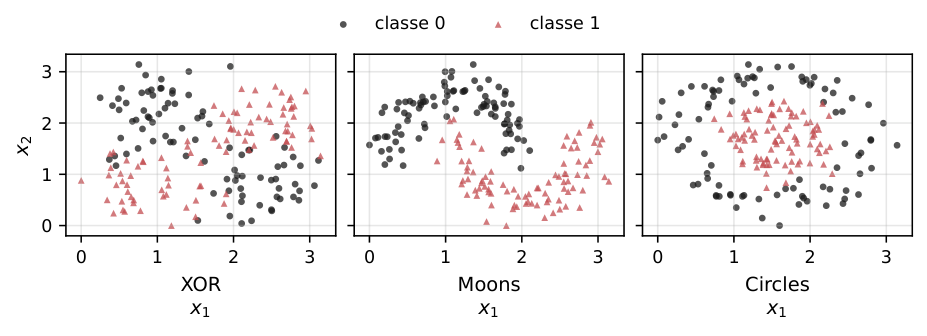

In [7]:
rodar_se_preciso(["figuras"], [FIGURES / "datasets.pdf"])
mostrar_figura(FIGURES / "datasets.pdf")

### A geometria de cada fronteira, como hipótese antes de treinar

- **xor**: fronteira em quadrantes. Nenhuma reta separa as classes, porque o rótulo depende
  de uma *interação* entre $x_1$ e $x_2$. Uma codificação que trate cada atributo
  isoladamente tende a sofrer aqui, e uma que correlacione os atributos (como o ZZ, que
  entrelaça já no bloco de dados) poderia levar vantagem.
- **moons**: fronteira curva e suave, mas conexa. É o caso mais benigno dos três.
- **circles**: fronteira fechada em torno do centro. Exige uma função radial ou periódica, e
  é onde o espectro de Fourier acessível pesa. O circuito produz
  $f_\theta(x) = \sum_\omega c_\omega(\theta)\, e^{i\omega x}$, e mais frequências (o
  *data re-uploading*) deveriam ajudar.

São **hipóteses**, anotadas antes de treinar. A seção 4 as confronta com os experimentos.

### Bruto × normalizado

A normalização muda a escala, não a forma. Os dois painéis usam os mesmos `n_samples`,
`noise` e semente do protocolo: à esquerda as 300 amostras do `make_moons`, à direita o
treino depois do `MinMaxScaler`, com as linhas pontilhadas em $0$ e $\pi$.

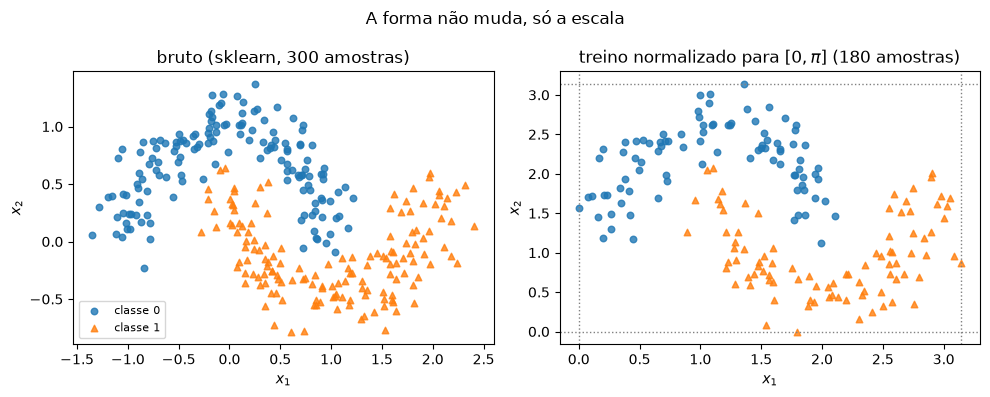

In [8]:
from sklearn.datasets import make_moons

NOMES = list(PADRAO.datasets_grade)
datasets = {nome: load_dataset(nome, seed=PADRAO.seed) for nome in NOMES}

X_bruto, y_bruto = make_moons(n_samples=PADRAO.n_samples, noise=PADRAO.noise, random_state=PADRAO.seed)
ds = datasets["moons"]

fig, eixos = plt.subplots(1, 2, figsize=(10, 4))
for classe, marcador in ((0, "o"), (1, "^")):
    eixos[0].scatter(*X_bruto[y_bruto == classe].T, marker=marcador, s=22, alpha=0.8, label=f"classe {classe}")
    eixos[1].scatter(*ds.X_train[ds.y_train == classe].T, marker=marcador, s=22, alpha=0.8)
eixos[0].set_title(f"bruto (sklearn, {len(X_bruto)} amostras)")
eixos[0].legend(loc="lower left", fontsize=8)
for v in (0, np.pi):
    eixos[1].axhline(v, ls=":", lw=1, color="gray")
    eixos[1].axvline(v, ls=":", lw=1, color="gray")
eixos[1].set_title(rf"treino normalizado para $[0, \pi]$ ({len(ds.X_train)} amostras)")
for eixo in eixos:
    eixo.set_xlabel("$x_1$")
    eixo.set_ylabel("$x_2$")
fig.suptitle("A forma não muda, só a escala")
fig.tight_layout()
plt.show()

### Tamanhos, balanceamento e limites por partição

O treino tem mínimo $0$ e máximo $\pi$ exatos. Validação e teste podem sair **um pouco fora**
de $[0, \pi]$, e isso é proposital: o `MinMaxScaler` é ajustado **só no treino**, e um ponto
de validação ou de teste mais extremo que todos os de treino extrapola. Ajustar o scaler no
conjunto inteiro faria os limites baterem, mas vazaria informação da validação e do teste
para o treino e inflaria a acurácia. Seria um número mais bonito e um resultado inválido.

In [9]:
linhas = []
for nome, d in datasets.items():
    linha = {"conjunto": nome}
    for parte, X, y in (("treino", d.X_train, d.y_train), ("val", d.X_val, d.y_val), ("teste", d.X_test, d.y_test)):
        linha[f"n_{parte}"] = len(X)
        linha[f"frac1_{parte}"] = round(float(y.mean()), 3)
        linha[f"min_{parte}"] = round(float(X.min()), 3)
        linha[f"max_{parte}"] = round(float(X.max()), 3)
    linhas.append(linha)
resumo_dados = pd.DataFrame(linhas).set_index("conjunto")
print(f"π = {np.pi:.3f}")
resumo_dados

π = 3.142


,n_treino,frac1_treino,min_treino,max_treino,n_val,frac1_val,min_val,max_val,n_teste,frac1_teste,min_teste,max_teste
conjunto,,,,,,,,,,,,
xor,180,0.511,0.0,3.142,60,0.5,0.157,3.239,60,0.5,0.102,2.968
moons,180,0.500,0.0,3.142,60,0.5,-0.063,3.294,60,0.5,-0.006,3.089
circles,180,0.500,0.0,3.142,60,0.5,0.157,3.060,60,0.5,-0.113,3.082


### Por que $[0, \pi]$ e não $[0, 2\pi]$

Na rotação $R_Y(\theta)$ aplicada a $|0\rangle$, o valor esperado é $\langle Z \rangle = \cos\theta$.
Quando $\theta$ vai de $0$ a $\pi$, $\cos\theta$ percorre $[-1, 1]$ **uma única vez**. Passando
de $\pi$, ele volta: $\theta$ e $2\pi - \theta$ dariam o mesmo estado, e dois valores distintos
de entrada se tornariam indistinguíveis antes de o treino começar. O intervalo $[0, \pi]$ é,
portanto, o maior que o *angle* aceita sem perder informação. A seção 4 (`diagnostico`) mostra
o que acontece com o *amplitude* quando a normalização muda.

## 2. Anatomia do classificador

A cadeia completa, a mesma para as quatro codificações:

$$x \;\mapsto\; \psi(x) \;\mapsto\; U(\theta)\,\psi(x) \;\mapsto\; \langle Z_0 \rangle + b \;\mapsto\; \hat{y}$$

O bloco de dados $x \mapsto \psi(x)$ é a codificação, a única parte que varia. $U(\theta)$ é o
ansatz congelado (`StronglyEntanglingLayers`, 2 camadas). A medição de $Z_0$ e o viés
clássico $b$ são iguais para todos.

O seletor abaixo monta cada circuito com `tccqml.model.build`, a mesma função que a CLI usa,
com pesos iniciais da semente do protocolo, e mostra três coisas:

1. **o bloco de custo**, o mesmo que o `treinar` imprime, com a contagem atual de
   *parameter-shift*: $2p + 1$ avaliações por amostra, $(2p + 1)|B|$ por passo e
   $(2p + 1)|B|S$ shots por passo;
2. **o circuito**, primeiro em blocos e depois com `level="device"`, as portas que a máquina
   executaria;
3. **o estado $\psi(x)$** só do bloco de dados, para o ponto de exemplo $x = (0{,}5;\ 2{,}0)$,
   com amplitude e probabilidade por base.

In [10]:
X_EXEMPLO = [0.5, 2.0]


def montar(encoding, n_layers=PADRAO.n_layers, ansatz=PADRAO.ansatz, L_reup=PADRAO.L_reup):
    # Mesma chamada de `python -m tccqml treinar` (cli._treinar).
    enc_kwargs = {"L_reup": L_reup} if encoding == "reuploading" else None
    return model.build(encoding, n_features=2, n_layers=n_layers, ansatz=ansatz, enc_kwargs=enc_kwargs)


def estado_codificado(clf, x=X_EXEMPLO) -> np.ndarray:
    # psi(x): só o bloco de dados, sem camadas treináveis (no re-uploading, os L blocos S(x)).
    enc = get_encoding(clf.encoding, **(clf.enc_kwargs or {}))

    @qml.qnode(qml.device("default.qubit", wires=clf.n_qubits))
    def so_codificacao(x):
        enc.bloco_de_dados()(x, wires=range(clf.n_qubits))
        return qml.state()

    return np.asarray(so_codificacao(pnp.array(x, requires_grad=False)))


def anatomia(encoding, **kwargs) -> None:
    clf = montar(encoding, **kwargs)
    weights, alpha, _ = model.pesos_iniciais(clf, seed=PADRAO.seed)
    x = pnp.array(X_EXEMPLO, requires_grad=False)

    print(f"codificação: {encoding}   qubits: {clf.n_qubits}   p (circuito): {clf.n_params_circuito}   "
          f"treináveis com o viés: {clf.n_params}")
    print()
    print(formatar(stats(clf, X_EXEMPLO, batch_size=PADRAO.batch_efetivo, shots=PADRAO.shots)))
    print("\ncircuito em blocos:")
    print(qml.draw(clf.circuit, max_length=120, show_matrices=False)(x, weights, alpha))
    print('\ncircuito no nível do dispositivo (level="device"):')
    print(qml.draw(clf.circuit, level="device", max_length=140)(x, weights, alpha))

    psi = estado_codificado(clf)
    print(f"\npsi(x) do bloco de dados, x = {X_EXEMPLO}   (norma {np.sum(np.abs(psi) ** 2):.8f})")
    for i, amp in enumerate(psi):
        base = format(i, f"0{clf.n_qubits}b")
        print(f"  |{base}>  amplitude {amp.real:+.4f}{amp.imag:+.4f}i   probabilidade {abs(amp) ** 2:.4f}")
    if clf.n_qubits == 2:
        # Concorrência de um estado puro de 2 qubits: 0 para estado produto, 1 para maximamente entrelaçado.
        concorrencia = 2 * abs(psi[0] * psi[3] - psi[1] * psi[2])
        tipo = "produto (sem entrelaçamento)" if concorrencia < 1e-9 else "ENTRELAÇADO"
        print(f"  concorrência C = 2|a00 a11 - a01 a10| = {concorrencia:.4f}  ->  estado {tipo}")
    else:
        print("  um só qubit: não há par para entrelaçar")

In [11]:
if USAR_WIDGETS and widgets is not None:
    seletor = widgets.ToggleButtons(options=list(PADRAO.encodings_grade), value="angle", description="codificação")
    saida_anatomia = widgets.Output()

    def _redesenhar(_=None):
        saida_anatomia.clear_output(wait=True)
        with saida_anatomia:
            anatomia(seletor.value)

    seletor.observe(_redesenhar, names="value")
    _redesenhar()
    display(widgets.VBox([seletor, saida_anatomia]))
else:
    print("Sem widgets: use a célula abaixo.")

Sem widgets: use a célula abaixo.


*Alternativa sem widgets:* troque `ANATOMIA` e rode a célula. Ela só desenha quando
`USAR_WIDGETS = False` ou quando o `ipywidgets` não está instalado.

In [12]:
ANATOMIA = "angle"  # angle | amplitude | reuploading | zz

if USAR_WIDGETS and widgets is not None:
    print("O seletor acima está em uso (USAR_WIDGETS = True).")
else:
    anatomia(ANATOMIA)

codificação: angle   qubits: 2   p (circuito): 12   treináveis com o viés: 13

  qubits ............... 2
  profundidade total ... 11
  profundidade codif. .. 1
  portas de 1 qubit .... 14
  portas de 2 qubits ... 4
  parâmetros (p) ....... 12
  aval. deslocadas ..... 24  por amostra (2p, Eq. 2.47)
  aval. p/ gradiente ... 25  por amostra (2p + 1)
  aval. por passo ...... 500  ((2p + 1)|B|)
  shots por passo ...... 500,000  ((2p + 1)|B|S)

circuito em blocos:
0: ─╭AngleEmbedding(M0)─╭StronglyEntanglingLayers(M1)─┤  <Z>
1: ─╰AngleEmbedding(M0)─╰StronglyEntanglingLayers(M1)─┤     

circuito no nível do dispositivo (level="device"):
0: ──RY(0.50)──Rot(0.03,-0.10,0.08)──╭●─╭X──Rot(0.01,-0.03,-0.00)─╭●─╭X─┤  <Z>
1: ──RY(2.00)──Rot(0.09,-0.20,-0.13)─╰X─╰●──Rot(-0.09,0.09,0.08)──╰X─╰●─┤     

psi(x) do bloco de dados, x = [0.5, 2.0]   (norma 1.00000000)
  |00>  amplitude +0.5235+0.0000i   probabilidade 0.2741
  |01>  amplitude +0.8153+0.0000i   probabilidade 0.6647
  |10>  amplitude +0.1337+0

### Como ler o desenho de cada codificação

- **`angle`**: `RY(0.50)` e `RY(2.00)` *são* os dados, um qubit por atributo. O bloco de
  dados tem profundidade 1 e nenhuma CNOT. $p = 12$ (2 camadas × 2 qubits × 3 ângulos do `Rot`).
- **`amplitude`**: os dois atributos viram as duas amplitudes de **um único qubit**, depois de
  normalizados. Com um qubit não há CNOT, e o ansatz se adapta ao número de qubits que a
  codificação determina: $p$ cai de 12 para **6**. A normalização descarta a norma de $x$, e
  dois pontos na mesma direção viram o mesmo estado.
- **`reuploading`**: o mesmo `RY` do *angle*, repetido $L = 3$ vezes. O ansatz **não vem
  depois**: uma camada treinável fica intercalada entre cada par de blocos de dados (Eq. 2.64),
  e por isso $p = 6L = $ **18**.
- **`zz`**: `Hadamard`, `RZ(2 x_i)` e, para o par, `CNOT · RZ · CNOT`, repetidos $r = 2$ vezes.
  É a **única codificação em que o próprio bloco de dados entrelaça**: as 4 CNOTs do bloco
  somam-se às 4 do ansatz.

### Estado produto × entrelaçado

No $\psi(x)$ acima, a concorrência diz se o bloco de dados já entrelaça. No **angle** e no
**reuploading** o bloco de dados é feito de rotações independentes por qubit, então o estado é
**produto** e o entrelaçamento só aparece no ansatz (o anel de CNOTs). No **amplitude** não
aparece em lugar nenhum, porque há um qubit só. No **zz** o estado **já sai entrelaçado** do
bloco de dados, antes de qualquer parâmetro treinável: é a correlação entre os atributos
introduzida pela própria codificação. O `ablacao` da seção 4 mede o que acontece quando o
ansatz perde as CNOTs.

### Retropropagação no simulador × *parameter-shift* contado

O treino calcula o gradiente por **retropropagação sobre o simulador**: o `default.qubit`
diferencia o próprio código da simulação, o caminho mais barato em software. O
*parameter-shift*, que é o que valeria em hardware real, **não é executado**: é contado
analiticamente em `circuit_stats.py`. O gradiente do custo quadrático é
$2\,(f(x) + b - y)\,\partial f/\partial\theta$. As $2p$ avaliações deslocadas (Eq. 2.47) dão
$\partial f/\partial\theta$, e o resíduo pede mais uma, sem deslocamento: $2p + 1$ por
amostra. Com $|B| = 20$ e $S = 1000$ shots, isso dá as linhas "aval. por passo" e "shots por
passo" do bloco de custo. O viés $b$ não entra, porque sua derivada é clássica. A atualização
é feita pelo Adam, um otimizador clássico, e é essa combinação que torna o modelo
**híbrido quântico-clássico**.

### O espectro previsto

Um bloco de dados feito de rotações de Pauli torna a saída uma série de Fourier truncada,
$f_\theta(x) = \sum_{\omega \in \Omega} c_\omega(\theta)\, e^{i\omega x}$. Quem fixa $\Omega$ é a
**codificação**; o ansatz só escolhe os coeficientes. No *angle*, $\Omega = \{-1, 0, 1\}$ por
atributo: poucas frequências, fronteiras suaves. No *re-uploading* com $L$ blocos,
$\Omega = \{-L, \dots, L\}$. $\Omega$ é um limite superior, e o `espectro` da seção 4 mede quanto
dele aparece de fato. Para *amplitude* e *zz* a saída não é uma série de Fourier em $x$, e a
previsão não se aplica.

## 3. Treino interativo

O painel espelha as opções de `python -m tccqml treinar`, com os padrões de `PADRAO`. Ao
clicar em **Treinar**, o notebook mostra o comando equivalente e executa **exatamente esse
comando**, com `--salvar` e `--out results/notebook`, para não tocar nos resultados oficiais.
Treinar é uma ação explícita e leva segundos, por isso o treino roda sempre, com qualquer valor
de `RODAR`.
O `--salvar` grava três arquivos:

- `metrics/<nome>.csv`: o histórico por época (custo, acurácia de treino e de validação);
- `metrics/<nome>_resumo.csv`: uma linha com a época escolhida e as três acurácias;
- `weights/<nome>.npz`: os pesos da época escolhida, de onde sai a fronteira de decisão sem retreinar.

O `<nome>` é `treino_<encoding>_<dataset>_<seed>` e ganha um sufixo para cada opção fora do
protocolo, para que dois treinos diferentes não se sobrescrevam.

### A divisão 60/20/20

As 300 amostras viram **180 de treino, 60 de validação e 60 de teste**. O treino ajusta os
pesos. A **validação escolhe a época de parada**: a cada época o histórico registra a acurácia
de validação, e no fim os parâmetros restaurados são os da época de maior acurácia de
validação (no empate, a mais antiga). O **teste é medido uma única vez**, nesse modelo, e nunca
aparece nas curvas. Se a acurácia de teste fosse olhada época a época, escolher a melhor seria
ajustar ao teste, e o número reportado deixaria de estimar a generalização. É também por
isso que a validação costuma sair um pouco acima do teste: ela é o máximo de uma curva ruidosa.

Com a configuração do protocolo e uma semente da grade, o resultado é **idêntico** ao da linha
correspondente de `comparar`, e o painel confere isso no fim.

**O que experimentar:** `angle` contra `reuploading` no `circles` é o par que mais mostra o efeito
do espectro na fronteira. Com o `angle`, as fronteiras saem suaves, de frequência 1. Com o
`amplitude`, saem retas pela origem, de um modelo de 1 qubit e $p = 6$. Mudar camadas, épocas ou
`lr` sai do protocolo, e o painel avisa quando a comparação com a grade deixa de valer.

In [13]:
def args_treinar(encoding, dataset, ansatz, L_reup, n_layers, epocas, lr, seed) -> list:
    args = ["treinar", "--encoding", encoding, "--dataset", dataset, "--ansatz", ansatz]
    if encoding == "reuploading":
        args += ["--L-reup", L_reup]
    args += ["--n-layers", n_layers, "--epocas", epocas, "--lr", lr, "--seed", seed, "--salvar"]
    return [str(a) for a in args]


def arquivos_treino(nome) -> list:
    base = Path(OUT_TREINO)
    return [base / "metrics" / f"{nome}.csv", base / "metrics" / f"{nome}_resumo.csv", base / "weights" / f"{nome}.npz"]


def treinar_e_mostrar(encoding, dataset, ansatz, L_reup, n_layers, epocas, lr, seed, forcar=False) -> None:
    cfg = {"encoding": encoding, "dataset": dataset, "ansatz": ansatz, "L_reup": L_reup,
           "n_layers": n_layers, "epocas": epocas, "lr": lr, "seed": seed}
    nome = nome_treino(SimpleNamespace(**cfg, n_samples=PADRAO.n_samples))  # o mesmo nome que a CLI grava
    args = args_treinar(**cfg)
    if forcar:
        tccqml(*args, out=OUT_TREINO)
    else:
        rodar_se_preciso(args, arquivos_treino(nome), out=OUT_TREINO)
    if faltando(arquivos_treino(nome)):
        return
    mostrar_treino(nome, **cfg)


def mostrar_treino(nome, encoding, dataset, ansatz, L_reup, n_layers, epocas, lr, seed) -> None:
    base = Path(OUT_TREINO)
    hist = pd.read_csv(base / "metrics" / f"{nome}.csv")
    res = pd.read_csv(base / "metrics" / f"{nome}_resumo.csv").iloc[0]
    pesos = np.load(base / "weights" / f"{nome}.npz")
    alpha = pesos["alpha"] if "alpha" in pesos.files else None
    weights, bias = pesos["weights"], float(pesos["bias"])
    clf = montar(encoding, n_layers=n_layers, ansatz=ansatz, L_reup=L_reup)
    ds = load_dataset(dataset, seed=seed)
    escolhida = int(res["epoca_escolhida"])

    display(Markdown(f"### Resultado: `{nome}`"))
    print(f"época escolhida pela validação: {escolhida} de {len(hist)}")
    print(f"acurácia  treino {res['acc_treino']:.3f}   validação {res['acc_val']:.3f}   teste {res['acc_teste']:.3f}")
    previsto = model.prever(clf, weights, alpha, bias, ds.X_test)
    print(f"conferência: acurácia de teste recalculada dos pesos gravados = {np.mean(np.asarray(previsto) == ds.y_test):.3f}")
    print()
    print(formatar(stats(clf, ds.X_train[0], batch_size=PADRAO.batch_efetivo, shots=PADRAO.shots)))
    print("\ncircuito com os pesos da época escolhida, no ponto de exemplo (nível do dispositivo):")
    print(qml.draw(clf.circuit, level="device", max_length=140)(pnp.array(X_EXEMPLO, requires_grad=False), weights, alpha))

    figs = base / "figures"
    figs.mkdir(parents=True, exist_ok=True)
    fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
    eixos[0].plot(hist["epoca"], hist["custo"], marker="o", ms=3)
    eixos[0].set(xlabel="época", ylabel="custo quadrático de treino", title="Convergência")
    eixos[1].plot(hist["epoca"], hist["acc_treino"], marker="o", ms=3, label="treino")
    eixos[1].plot(hist["epoca"], hist["acc_val"], marker="s", ms=3, label="validação")
    eixos[1].axhline(0.5, ls="--", lw=1, color="gray", label="acaso (0,5)")
    eixos[1].set(xlabel="época", ylabel="acurácia", ylim=(0.4, 1.02), title="Acurácia (o teste não entra aqui)")
    for eixo in eixos:
        eixo.axvline(escolhida, ls=":", lw=1.2, color="k", label="época escolhida")
    eixos[1].legend(loc="lower right", fontsize=8)
    fig.suptitle(f"{encoding} · {dataset} · semente {seed}")
    fig.tight_layout()
    fig.savefig(figs / f"{nome}_curvas.png", dpi=150, bbox_inches="tight")
    plt.show()

    grade = np.linspace(-0.1, np.pi + 0.1, 60)
    G1, G2 = np.meshgrid(grade, grade)
    z = np.asarray(
        model.saida_continua(clf, weights, alpha, bias, np.column_stack([G1.ravel(), G2.ravel()])), dtype=float
    ).reshape(G1.shape)
    fig, eixo = plt.subplots(figsize=(6, 5))
    mapa = eixo.contourf(G1, G2, z, levels=np.linspace(-1, 1, 21), cmap="RdBu", alpha=0.6, extend="both")
    eixo.contour(G1, G2, z, levels=[0.0], colors="k", linewidths=1.5)
    for classe, marcador, cor in ((0, "o", "#1b1b1b"), (1, "^", "#7a0f16")):
        m = ds.y_test == classe
        eixo.scatter(ds.X_test[m, 0], ds.X_test[m, 1], marker=marcador, c=cor, s=34,
                     edgecolors="white", linewidths=0.6, label=f"classe {classe} (teste)")
    eixo.set(xlabel="$x_1$", ylabel="$x_2$", title=f"Fronteira aprendida: {encoding} · {dataset}")
    eixo.legend(loc="upper right", fontsize=8)
    fig.colorbar(mapa, ax=eixo, label=r"$\langle Z_0\rangle + b$  (negativo: prevê classe 0)")
    fig.tight_layout()
    fig.savefig(figs / f"{nome}_fronteira.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"figuras salvas em {figs.as_posix()}/")

    # Esta semente foi típica? Compara com a média e o desvio da grade oficial.
    protocolo = (ansatz == PADRAO.ansatz and n_layers == PADRAO.n_layers and lr == PADRAO.lr
                 and epocas == PADRAO.epocas and (encoding != "reuploading" or L_reup == PADRAO.L_reup))
    caminho = METRICS / "resumo.csv"
    if not caminho.exists():
        print(f"\n({caminho.as_posix()} não existe: rode `comparar` para comparar com a grade.)")
        return
    resumo = pd.read_csv(caminho)
    linha = resumo[(resumo["encoding"] == encoding) & (resumo["dataset"] == dataset)]
    if linha.empty:
        print(f"\n{encoding} × {dataset} não faz parte da grade.")
        return
    linha = linha.iloc[0]
    media, desvio = linha["acc_teste_mean"], linha["acc_teste_std"]
    print(f"\ngrade oficial (`comparar`, {int(linha['acc_teste_count'])} sementes): teste {media:.3f} ± {desvio:.3f}")
    distancia = (res["acc_teste"] - media) / desvio if desvio > 0 else 0.0
    print(f"este treino: {res['acc_teste']:.3f}, a {distancia:+.1f} desvio(s) da média "
          f"({'típico' if abs(distancia) <= 1 else 'fora de 1 desvio'})")
    if not protocolo:
        print("atenção: esta configuração foge do protocolo da grade; a comparação é só indicativa.")
    elif seed in PADRAO.sementes and (METRICS / "por_treino.csv").exists():
        pt = pd.read_csv(METRICS / "por_treino.csv")
        mesma = pt[(pt["encoding"] == encoding) & (pt["dataset"] == dataset) & (pt["seed"] == seed)]
        if len(mesma):
            g = mesma.iloc[0]
            igual = all(np.isclose(g[c], res[c]) for c in ("acc_treino", "acc_val", "acc_teste")) \
                and int(g["epoca_escolhida"]) == escolhida
            print(f"mesma semente na grade: treino {g['acc_treino']:.3f}, val {g['acc_val']:.3f}, "
                  f"teste {g['acc_teste']:.3f}, época {int(g['epoca_escolhida'])} -> "
                  f"{'idêntico ao terminal ✓' if igual else 'DIFERENTE ✗ (investigar)'}")

In [14]:
if USAR_WIDGETS and widgets is not None:
    estilo = {"description_width": "70px"}
    campos = {
        "encoding": widgets.Dropdown(options=sorted(ENCODINGS), value="angle", description="encoding", style=estilo),
        "dataset": widgets.Dropdown(options=sorted(_GENERATORS), value="moons", description="dataset", style=estilo),
        "ansatz": widgets.Dropdown(options=sorted(ANSATZE), value=PADRAO.ansatz, description="ansatz", style=estilo),
        "L_reup": widgets.BoundedIntText(value=PADRAO.L_reup, min=1, max=10, description="L-reup", style=estilo),
        "n_layers": widgets.BoundedIntText(value=PADRAO.n_layers, min=1, max=10, description="n-layers", style=estilo),
        "epocas": widgets.BoundedIntText(value=PADRAO.epocas, min=1, max=500, description="epocas", style=estilo),
        "lr": widgets.BoundedFloatText(value=PADRAO.lr, min=1e-4, max=10.0, step=0.01, description="lr", style=estilo),
        "seed": widgets.IntText(value=PADRAO.seed, description="seed", style=estilo),
    }
    botao = widgets.Button(description="Treinar", button_style="primary", icon="play")
    comando_html = widgets.HTML()
    saida_treino = widgets.Output()

    def _cfg():
        return {chave: campo.value for chave, campo in campos.items()}

    def _atualizar_comando(_=None):
        campos["L_reup"].disabled = campos["encoding"].value != "reuploading"
        texto = como_no_terminal(comando(*args_treinar(**_cfg()), out=OUT_TREINO))
        comando_html.value = f"comando equivalente: <code>{texto}</code>"

    def _treinar(_):
        botao.disabled = True
        saida_treino.clear_output()
        try:
            with saida_treino:
                treinar_e_mostrar(**_cfg(), forcar=True)
        finally:
            botao.disabled = False

    for campo in campos.values():
        campo.observe(_atualizar_comando, names="value")
    botao.on_click(_treinar)
    _atualizar_comando()
    display(widgets.VBox([
        widgets.HBox([campos["encoding"], campos["dataset"], campos["ansatz"]]),
        widgets.HBox([campos["L_reup"], campos["n_layers"], campos["epocas"]]),
        widgets.HBox([campos["lr"], campos["seed"], botao]),
        comando_html,
        saida_treino,
    ]))
else:
    print("Sem widgets: use as duas células abaixo.")

Sem widgets: use as duas células abaixo.


### Alternativa sem widgets

Para abrir fora do Jupyter ou do VS Code: edite `TREINO` e rode a célula seguinte. Como o botão,
ela **sempre treina**, com qualquer valor de `RODAR`, e sobrescreve o treino anterior da mesma
configuração. Só roda quando `USAR_WIDGETS = False` ou quando o `ipywidgets` não está instalado.

In [15]:
TREINO = {
    "encoding": "angle",          # angle | amplitude | reuploading | zz
    "dataset": "moons",           # xor | moons | circles
    "ansatz": PADRAO.ansatz,      # strongly_entangling | local
    "L_reup": PADRAO.L_reup,      # só vale para reuploading
    "n_layers": PADRAO.n_layers,
    "epocas": PADRAO.epocas,
    "lr": PADRAO.lr,
    "seed": PADRAO.seed,
}

$ python -m tccqml --out results/notebook treinar --encoding angle --dataset moons --ansatz strongly_entangling --n-layers 2 --epocas 30 --lr 0.1 --seed 42 --salvar


codificação: angle   dataset: moons   ansatz: strongly_entangling


custo do circuito:


  qubits ............... 2


  profundidade total ... 11


...

resumo salvo em results\notebook\metrics\treino_angle_moons_42_resumo.csv


pesos salvos em results\notebook\weights\treino_angle_moons_42.npz


[ok em 12 s]


### Resultado: `treino_angle_moons_42`

época escolhida pela validação: 4 de 30
acurácia  treino 0.906   validação 0.817   teste 0.800
conferência: acurácia de teste recalculada dos pesos gravados = 0.800

  qubits ............... 2
  profundidade total ... 11
  profundidade codif. .. 1
  portas de 1 qubit .... 14
  portas de 2 qubits ... 4
  parâmetros (p) ....... 12
  aval. deslocadas ..... 24  por amostra (2p, Eq. 2.47)
  aval. p/ gradiente ... 25  por amostra (2p + 1)
  aval. por passo ...... 500  ((2p + 1)|B|)
  shots por passo ...... 500,000  ((2p + 1)|B|S)

circuito com os pesos da época escolhida, no ponto de exemplo (nível do dispositivo):
0: ──RY(0.50)──Rot(-0.12,-1.64,0.25)─╭●─╭X──Rot(0.01,-0.03,-0.00)─╭●─╭X─┤  <Z>
1: ──RY(2.00)──Rot(-0.36,0.13,-0.13)─╰X─╰●──Rot(0.09,-0.48,0.08)──╰X─╰●─┤     


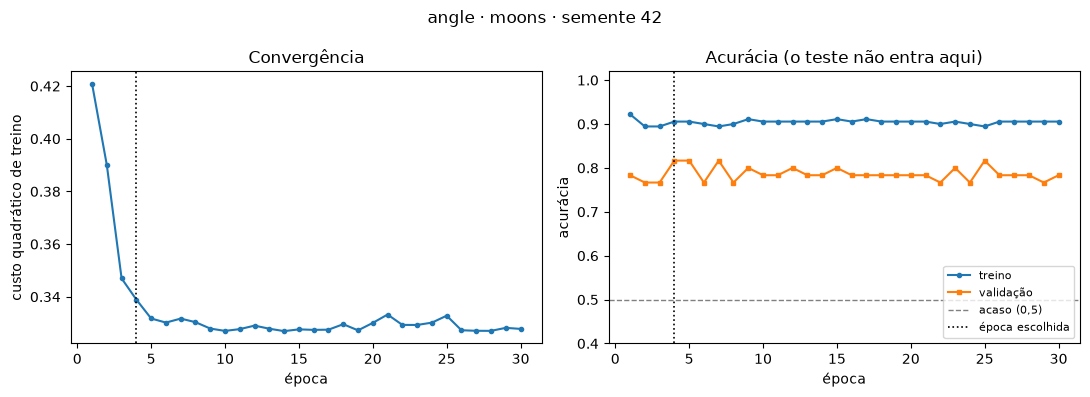

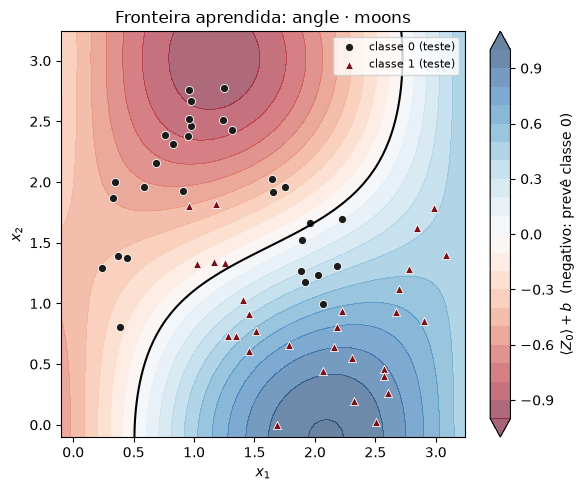

figuras salvas em results/notebook/figures/

grade oficial (`comparar`, 5 sementes): teste 0.847 ± 0.032
este treino: 0.800, a -1.5 desvio(s) da média (fora de 1 desvio)
mesma semente na grade: treino 0.906, val 0.817, teste 0.800, época 4 -> idêntico ao terminal ✓


In [16]:
if USAR_WIDGETS and widgets is not None:
    print("O painel acima está em uso (USAR_WIDGETS = True).")
else:
    treinar_e_mostrar(**TREINO, forcar=True)

## 4. Os experimentos do TCC

Uma seção por subcomando, na ordem em que o trabalho os roda. Cada uma tem a pergunta, a
célula que roda (respeitando `RODAR` e os arquivos existentes), a leitura dos CSVs, a
tabela-resumo, as figuras correspondentes e um parágrafo de interpretação.

As tabelas-resumo são as de `OUT_DIR/tables/`, as mesmas que vão para o Overleaf, e não uma
reagregação feita aqui. As figuras são as de `OUT_DIR/figures/`. Como as duas vêm dos comandos
`tabelas` e `figuras`, que só leem CSV (segundos), elas são regeneradas sempre que uma seção
executa de fato o seu experimento. A célula abaixo garante que existam desde já, se os CSVs já
estiverem prontos.

Os tempos citados são de treino numa CPU comum, sem GPU. Onde o CSV tem a coluna `segundos`, a
seção imprime o tempo medido.

In [17]:
ESPERADOS = {
    "comparar": [METRICS / f for f in ("comparacao.csv", "por_treino.csv", "resumo.csv")]
    + [WEIGHTS / f"{e}_{d}_{s}.npz" for e in PADRAO.encodings_grade for d in PADRAO.datasets_grade for s in PADRAO.sementes],
    "sensibilidade": [METRICS / "sensibilidade_lr.csv", METRICS / "resumo_sensibilidade_lr.csv"],
    "varredura_L": [METRICS / "varredura_L.csv"],
    "varredura_camadas": [METRICS / "varredura_camadas.csv"],
    "espectro": [METRICS / "espectro.csv"],
    "ablacao": [METRICS / "ablacao_entrelacamento.csv"],
    "diagnostico": [METRICS / "diagnostico_amplitude.csv"],
    "verificacoes": [METRICS / f for f in ("controle_linear.csv", "resumo_controle_linear.csv",
                                           "limiar_circles.csv", "resumo_limiar_circles.csv")],
}
TABELAS = ["tab_acuracia", "tab_custo", "tab_convergencia", "tab_espectro", "tab_ablacao",
           "tab_diagnostico", "tab_mesmo_p", "tab_sensibilidade", "tab_verificacoes", "tab_qualitativa"]
FIGURAS = ["datasets.pdf", "curvas-treinamento.pdf", "fronteiras-aprendidas.pdf", "acuracia-vs-custo.pdf",
           "custo-por-codificacao.pdf", "acuracia-vs-L.pdf", "espectro-reuploading.pdf",
           "sensibilidade-lr.pdf", "limiar-circles.pdf"]
SAIDAS_TABELAS = [TABLES / f"{t}.{ext}" for t in TABELAS for ext in ("tex", "csv")]
SAIDAS_FIGURAS = [FIGURES / f for f in FIGURAS]


def rodar_experimento(args, esperados) -> None:
    # Roda o experimento se preciso; se rodou, regenera tabelas e figuras com os CSVs novos.
    if rodar_se_preciso(args, esperados):
        print("\nAtualizando tabelas e figuras com os CSVs novos:")
        tccqml("tabelas")
        tccqml("figuras")


todos = [a for arquivos in ESPERADOS.values() for a in arquivos]
if not faltando(todos):
    rodar_se_preciso(["tabelas"], SAIDAS_TABELAS)
    rodar_se_preciso(["figuras"], SAIDAS_FIGURAS)
else:
    print(f"Faltam {len(faltando(todos))} arquivo(s) de experimentos. `tabelas` e `figuras` rodam depois "
          "de cada experimento executado abaixo e de novo na seção 5.")

[pulado] os arquivos de `python -m tccqml --out results tabelas` já existem (tab_acuracia.tex, tab_acuracia.csv, tab_custo.tex e mais 17).
[pulado] os arquivos de `python -m tccqml --out results figuras` já existem (datasets.pdf, curvas-treinamento.pdf, fronteiras-aprendidas.pdf e mais 6).


### 4.1 `comparar`: a grade principal

**Pergunta:** com tudo o mais congelado, qual codificação classifica melhor cada conjunto, e a
que custo?

**O que faz:** treina 4 codificações × 3 conjuntos × 5 sementes (60 treinos) com o protocolo
de `PADRAO`. **Grava** `metrics/comparacao.csv` (uma linha por treino e época),
`metrics/por_treino.csv` (uma linha por treino), `metrics/resumo.csv` (média e desvio entre
sementes, com os recursos do circuito) e `weights/<enc>_<dataset>_<seed>.npz`. **Tempo:**
cerca de 8 minutos de treino.

In [18]:
rodar_experimento(["comparar"], ESPERADOS["comparar"])

[pulado] os arquivos de `python -m tccqml --out results comparar` já existem (comparacao.csv, por_treino.csv, resumo.csv e mais 60).


In [19]:
por_treino = ler("por_treino.csv")
resumo = ler("resumo.csv")
if por_treino is not None:
    print(f"{por_treino['encoding'].nunique()} codificações × {por_treino['dataset'].nunique()} conjuntos × "
          f"{por_treino['seed'].nunique()} sementes")
    tempo_de_treino(por_treino)
    display(por_treino[["encoding", "dataset", "seed", "acc_treino", "acc_val", "acc_teste", "epoca_escolhida"]].head())
mostrar_tabela("tab_acuracia")
mostrar_tabela("tab_custo")
mostrar_tabela("tab_convergencia")

4 codificações × 3 conjuntos × 5 sementes
60 treinos, 7.9 min de treino somados (coluna `segundos`)


,encoding,dataset,seed,acc_treino,acc_val,acc_teste,epoca_escolhida
0,angle,xor,42,0.883333,0.900000,0.866667,5
1,angle,xor,43,0.877778,0.900000,0.800000,2
2,angle,xor,44,0.894444,0.916667,0.883333,25
3,angle,xor,45,0.877778,0.916667,0.900000,3
4,angle,xor,46,0.861111,0.916667,0.916667,2


**`tab_acuracia`** — mesma tabela de `results/tables/tab_acuracia.tex`

Codificação,XOR,Moons,Circles
Angle,"0,873 ± 0,045","0,847 ± 0,032","0,953 ± 0,025"
Amplitude,"0,693 ± 0,069","0,827 ± 0,019","0,783 ± 0,051"
Re-uploading,"0,870 ± 0,046","0,890 ± 0,045","0,957 ± 0,022"
Feature map ZZ,"0,683 ± 0,024","0,750 ± 0,068","0,880 ± 0,030"


**`tab_custo`** — mesma tabela de `results/tables/tab_custo.tex`

Codificação,p,Codif.: prof.,Codif.: portas,Codif.: CNOTs,Circuito: qubits,Circuito: prof.,Circuito: portas,Circuito: CNOTs,Desloc. (2p),Aval./amostra,Aval./passo,Shots/passo
Angle,12,1,2,0,2,11,18,4,24,25,500,500 000
Amplitude,6,2,2,0,1,8,8,0,12,13,260,260 000
Re-uploading,18,3,6,0,2,18,30,6,36,37,740,740 000
Feature map ZZ,12,10,14,4,2,20,30,8,24,25,500,500 000


**`tab_convergencia`** — mesma tabela de `results/tables/tab_convergencia.tex`

Codificação,XOR,Moons,Circles,Custo final médio
Angle,"1,4","1,0","8,8","0,501"
Amplitude,"1,6","1,0","2,8","0,684"
Re-uploading,"2,0","1,8","3,4","0,317"
Feature map ZZ,"1,4","1,6","1,0","0,605"


**`fronteiras-aprendidas.pdf`**

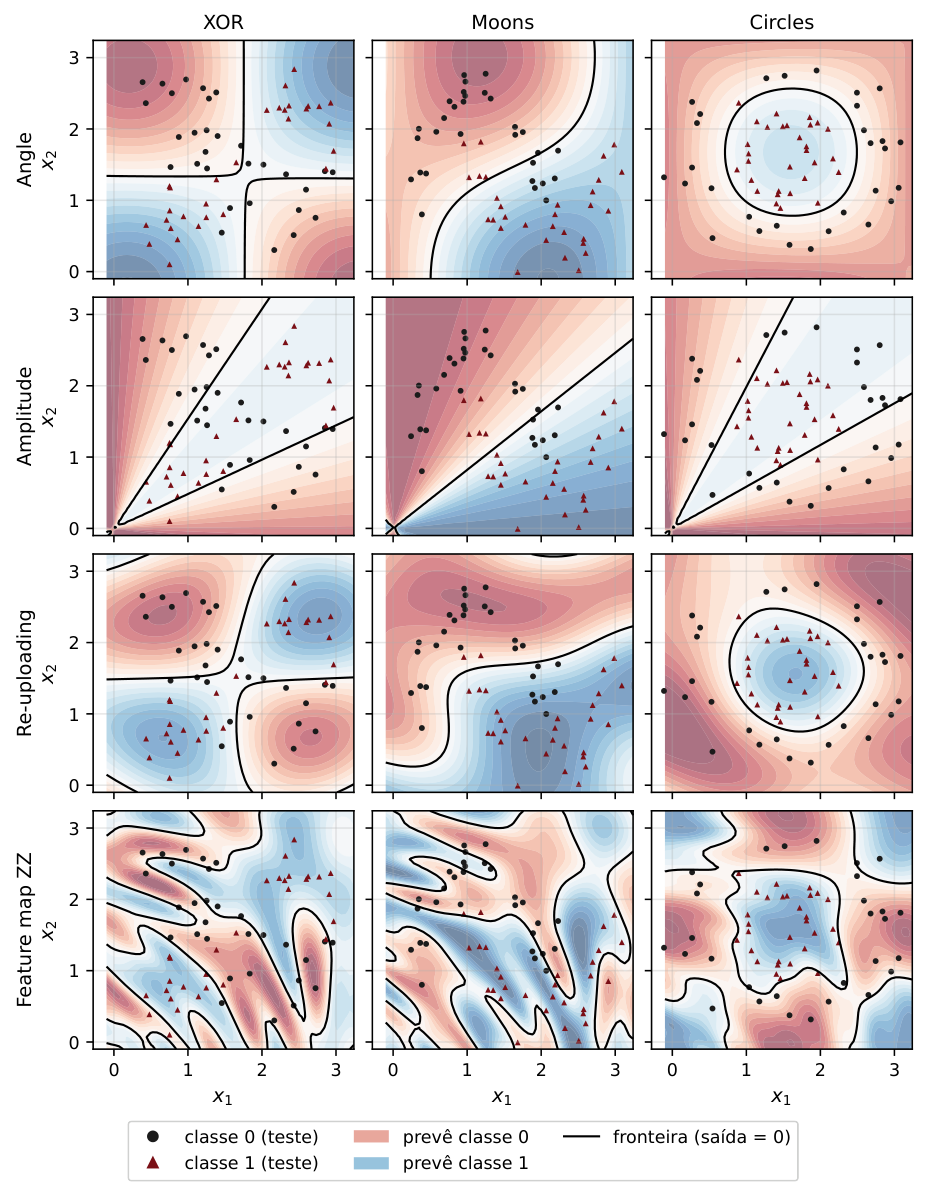

**`curvas-treinamento.pdf`**

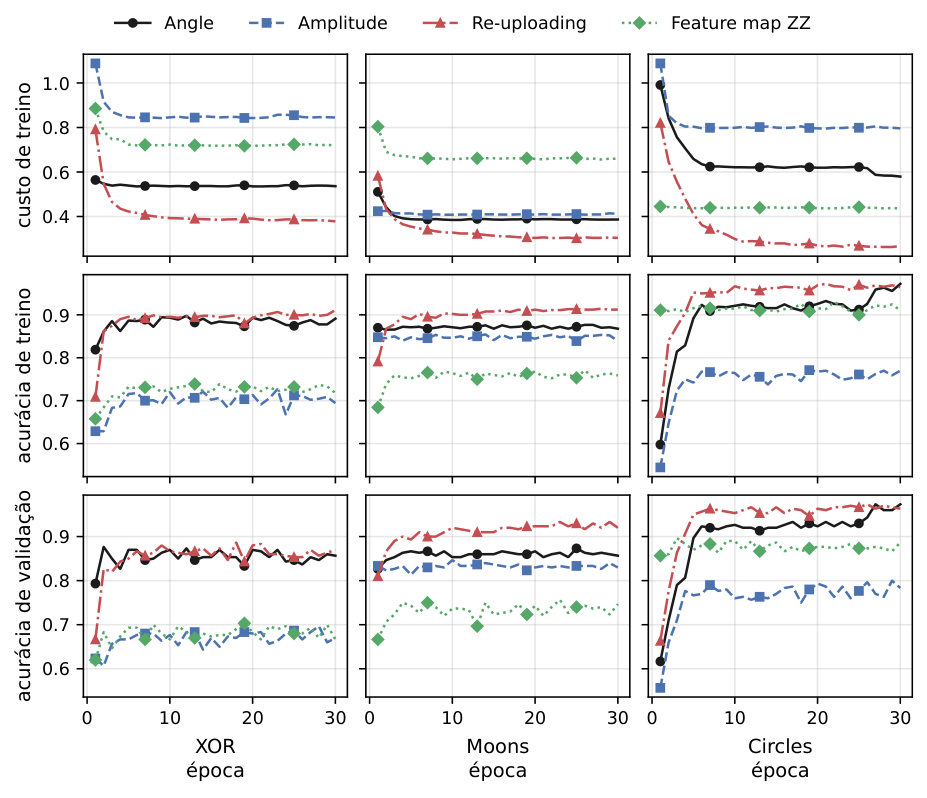

**`acuracia-vs-custo.pdf`**

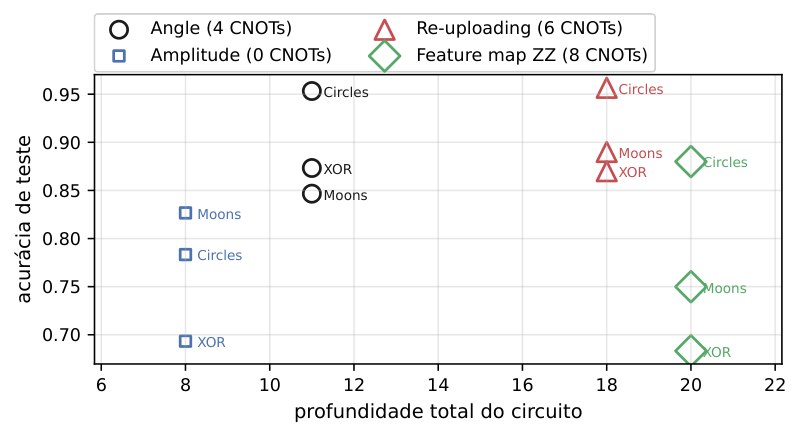

**`custo-por-codificacao.pdf`**

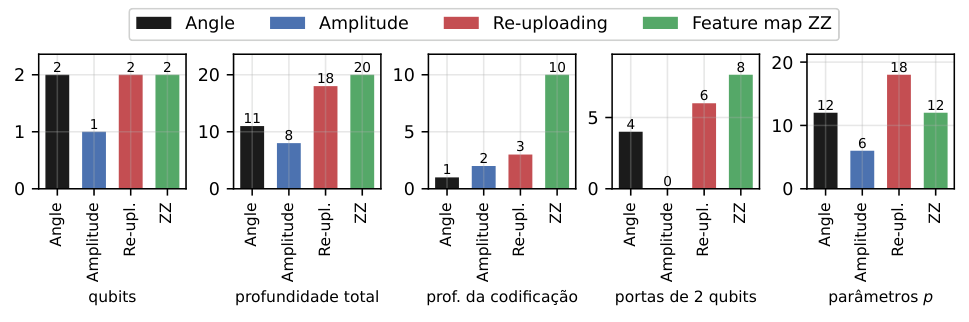

In [20]:
for figura in ("fronteiras-aprendidas.pdf", "curvas-treinamento.pdf", "acuracia-vs-custo.pdf", "custo-por-codificacao.pdf"):
    display(Markdown(f"**`{figura}`**"))
    mostrar_figura(FIGURES / figura)

**Como interpretar.** Leia a `tab_acuracia` por coluna, conjunto a conjunto: uma diferença
menor que o desvio entre sementes **não** sustenta uma ordem. Depois cruze com a `tab_custo` e
a `acuracia-vs-custo`, porque a tese é acurácia **pelo custo**: profundidade, CNOTs e shots
por passo. As fronteiras explicam as acurácias. O *angle* tem fronteiras suaves, de frequência
1. O *amplitude* é limitado a retas pela origem. O *re-uploading* desenha as mesmas formas com
mais flexibilidade. O ZZ tem fronteiras recortadas, que vêm das fases
$(\pi - x_1)(\pi - x_2)$ e não da estrutura dos dados. As curvas mostram se 30 épocas bastaram:
quase todas estabilizam cedo, e uma curva que ainda sobe no fim pede atenção.

### 4.2 `sensibilidade`: a taxa de aprendizado

**Pergunta:** quando uma codificação fica para trás, é a representação que não alcança a
fronteira ou só o otimizador que não chegou lá com o passo comum `lr = 0.1`?

**O que faz:** repete a grade variando **só** o `lr` sobre `PADRAO.lr_candidatos`, fixados antes
de rodar, com o mesmo orçamento para todas as codificações (4 valores × 5 sementes, 240
treinos). A taxa é escolhida pela maior acurácia média de **validação**, e o teste não
participa. **Grava** `metrics/sensibilidade_lr.csv` e `metrics/resumo_sensibilidade_lr.csv`,
sem tocar nos CSVs da grade. **Tempo:** cerca de quatro vezes o da grade.

In [21]:
rodar_experimento(["sensibilidade"], ESPERADOS["sensibilidade"])

[pulado] os arquivos de `python -m tccqml --out results sensibilidade` já existem (sensibilidade_lr.csv, resumo_sensibilidade_lr.csv).


240 treinos; candidatos: 0.01, 0.03, 0.1, 0.3


**lr escolhido pela validação** (linhas: codificação; colunas: conjunto)

dataset,circles,moons,xor
encoding,,,
amplitude,0.3,0.3,0.3
angle,0.1,0.3,0.1
reuploading,0.1,0.1,0.3
zz,0.3,0.3,0.1


**`tab_sensibilidade`** — mesma tabela de `results/tables/tab_sensibilidade.tex`

Codificação,XOR (protocolo),XOR (escolhido),Moons (protocolo),Moons (escolhido),Circles (protocolo),Circles (escolhido)
Angle,"0,873 ± 0,045","0,873 ± 0,045 (0,1)","0,847 ± 0,032","0,847 ± 0,059 (0,3)","0,953 ± 0,025","0,953 ± 0,025 (0,1)"
Amplitude,"0,693 ± 0,069","0,693 ± 0,056 (0,3)","0,827 ± 0,019","0,837 ± 0,022 (0,3)","0,783 ± 0,051","0,773 ± 0,045 (0,3)"
Re-uploading,"0,870 ± 0,046","0,870 ± 0,052 (0,3)","0,890 ± 0,045","0,890 ± 0,045 (0,1)","0,957 ± 0,022","0,957 ± 0,022 (0,1)"
Feature map ZZ,"0,683 ± 0,024","0,683 ± 0,024 (0,1)","0,750 ± 0,068","0,757 ± 0,061 (0,3)","0,880 ± 0,030","0,870 ± 0,027 (0,3)"


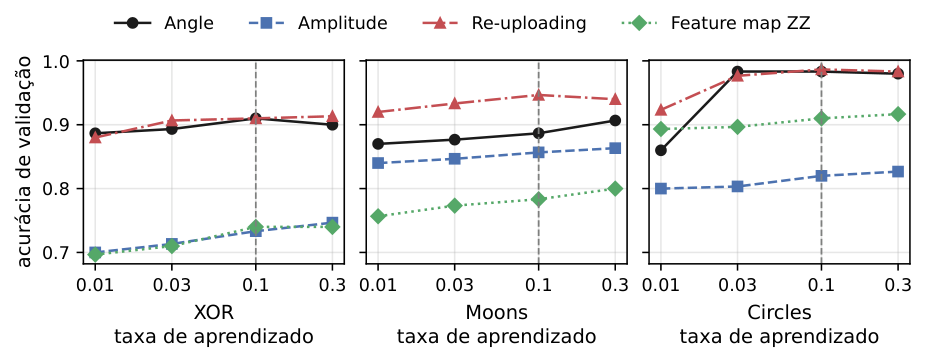

In [22]:
sens = ler("sensibilidade_lr.csv")
resumo_sens = ler("resumo_sensibilidade_lr.csv")
if sens is not None:
    print(f"{len(sens)} treinos; candidatos: {', '.join(f'{v:g}' for v in sorted(sens['lr'].unique()))}")
if resumo_sens is not None:
    display(Markdown("**lr escolhido pela validação** (linhas: codificação; colunas: conjunto)"))
    display(resumo_sens.pivot(index="encoding", columns="dataset", values="lr_escolhido"))
mostrar_tabela("tab_sensibilidade")
mostrar_figura(FIGURES / "sensibilidade-lr.pdf")

**Como interpretar.** Compare, na `tab_sensibilidade`, a coluna do protocolo com a do lr
escolhido. Se a acurácia de teste muda menos que o desvio, a codificação já estava tão bem
treinada com 0,1 quanto com a melhor das quatro taxas, e as desvantagens da tabela principal
não são falha de otimização. Um ganho na validação que não aparece no teste é em parte efeito
da própria escolha: o máximo de quatro médias ruidosas superestima. Na figura, uma curva plana
em torno da linha tracejada (o lr do protocolo) indica insensibilidade ao passo comum.

### 4.3 `varredura --parametro L-reup`: quantas repetições no re-uploading

**Pergunta:** a acurácia do *re-uploading* cresce com o número $L$ de blocos de dados, e até onde?

**O que faz:** treina o *re-uploading* com $L = 1, \dots, 5$ nos três conjuntos e 5 sementes
(75 treinos). O custo cresce linearmente: $p = 6L$. **Grava** `metrics/varredura_L.csv`.
**Tempo:** cerca de 15 minutos de treino, o experimento mais longo.

In [23]:
rodar_experimento(["varredura", "--parametro", "L-reup"], ESPERADOS["varredura_L"])

[pulado] os arquivos de `python -m tccqml --out results varredura --parametro L-reup` já existem (varredura_L.csv).


75 treinos, 14.6 min de treino somados (coluna `segundos`)


**Custo por L** (é o mesmo em todos os conjuntos)

,n_params_circuito,depth,gates_2q,n_shots_passo
L_reup,,,,
1,6,6,2,260000
2,12,12,4,500000
3,18,18,6,740000
4,24,24,8,980000
5,30,30,10,1220000


**Acurácia de teste do re-uploading por L** (colunas de re-uploading da `tab_mesmo_p`)

L ou camadas,p,XOR (re-up.),Moons (re-up.),Circles (re-up.)
1,6,"0,517 ± 0,058","0,807 ± 0,069","0,780 ± 0,046"
2,12,"0,880 ± 0,043","0,860 ± 0,043","0,943 ± 0,015"
3,18,"0,870 ± 0,046","0,890 ± 0,045","0,957 ± 0,022"
4,24,"0,880 ± 0,046","0,930 ± 0,032","0,957 ± 0,025"
5,30,"0,853 ± 0,055","0,953 ± 0,025","0,943 ± 0,030"


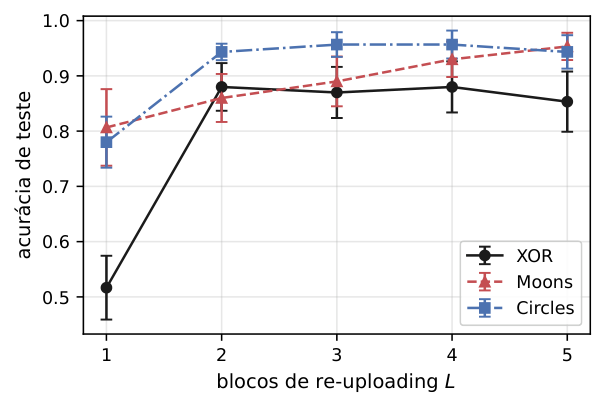

In [24]:
varredura_L = ler("varredura_L.csv")
if varredura_L is not None:
    tempo_de_treino(varredura_L)
    display(Markdown("**Custo por L** (é o mesmo em todos os conjuntos)"))
    display(varredura_L.groupby("L_reup")[["n_params_circuito", "depth", "gates_2q", "n_shots_passo"]].first())
caminho = TABLES / "tab_mesmo_p.csv"
if caminho.exists():
    # As colunas de re-uploading da tab_mesmo_p são a tabela da varredura de L no texto.
    tabela = pd.read_csv(caminho, dtype=str, keep_default_na=False)
    colunas = list(tabela.columns[:2]) + [c for c in tabela.columns if "re-up" in c]
    display(Markdown("**Acurácia de teste do re-uploading por L** (colunas de re-uploading da `tab_mesmo_p`)"))
    display(tabela[colunas].map(sem_latex).rename(columns=sem_latex).style.hide(axis="index"))
else:
    mostrar_tabela("tab_mesmo_p")
mostrar_figura(FIGURES / "acuracia-vs-L.pdf")

**Como interpretar.** Procure onde cada curva **estabiliza**: a partir daí, mais $L$ só custa
(profundidade e shots crescem linearmente) sem ganho além do desvio. Um $L = 1$ no nível do
acaso no *xor* não é falta de frequência, já que o *angle* tem a mesma frequência máxima e vai
bem. É uma perda da arquitetura, que o `espectro` (4.5) explica: com o anel de CNOTs e a medição
de $Z_0$, o último bloco de dados só alcança $x_2$. Com $L$ crescendo, porém, aumentam **ao
mesmo tempo** as frequências e os parâmetros, e a próxima seção separa os dois efeitos.

### 4.4 `varredura --parametro n-layers`: controle com o mesmo $p$

**Pergunta:** o ganho do *re-uploading* vem das frequências acessíveis ou só do número de
parâmetros?

**O que faz:** treina o *angle* com $k = 1, \dots, 5$ camadas no ansatz (75 treinos). Com dois
qubits cada camada tem 6 parâmetros, então o *angle* com $k$ camadas tem o mesmo $p = 6k$ do
*re-uploading* com $L = k$, mas continua com $\Omega = \{-1, 0, 1\}$. É uma exceção deliberada
ao protocolo, gravada num CSV próprio, `metrics/varredura_camadas.csv`. **Tempo:** alguns minutos.

In [25]:
rodar_experimento(["varredura", "--parametro", "n-layers"], ESPERADOS["varredura_camadas"])

[pulado] os arquivos de `python -m tccqml --out results varredura --parametro n-layers` já existem (varredura_camadas.csv).


In [26]:
varredura_camadas = ler("varredura_camadas.csv")
tempo_de_treino(varredura_camadas)
mostrar_tabela("tab_mesmo_p")
print("Este experimento não tem figura própria: a comparação é a tab_mesmo_p.")

75 treinos, 13.2 min de treino somados (coluna `segundos`)


**`tab_mesmo_p`** — mesma tabela de `results/tables/tab_mesmo_p.tex`

L ou camadas,p,XOR (angle),XOR (re-up.),Moons (angle),Moons (re-up.),Circles (angle),Circles (re-up.)
1,6,"0,517 ± 0,058","0,517 ± 0,058","0,807 ± 0,069","0,807 ± 0,069","0,780 ± 0,046","0,780 ± 0,046"
2,12,"0,873 ± 0,045","0,880 ± 0,043","0,847 ± 0,032","0,860 ± 0,043","0,953 ± 0,025","0,943 ± 0,015"
3,18,"0,853 ± 0,043","0,870 ± 0,046","0,843 ± 0,053","0,890 ± 0,045","0,957 ± 0,030","0,957 ± 0,022"
4,24,"0,870 ± 0,045","0,880 ± 0,046","0,843 ± 0,035","0,930 ± 0,032","0,933 ± 0,024","0,957 ± 0,025"
5,30,"0,887 ± 0,048","0,853 ± 0,055","0,847 ± 0,051","0,953 ± 0,025","0,943 ± 0,035","0,943 ± 0,030"


Este experimento não tem figura própria: a comparação é a tab_mesmo_p.


**Como interpretar.** Leia a `tab_mesmo_p` linha a linha, com o mesmo $p$ dos dois lados. Com
$k = 1$ os dois circuitos são idênticos, e com $k = 2$ o *angle* é o da grade principal, o que
serve de conferência. Se o *angle* fica parado com mais camadas enquanto o *re-uploading* sobe,
o ganho vem das **frequências**, não dos parâmetros. Se os dois empatam dentro do desvio, aquele
conjunto não pede frequências maiores.

### 4.5 `espectro`: $\Omega$ medido

**Pergunta:** as frequências que o modelo de fato representa respeitam o limite
$\Omega = \{-1, 0, 1\}$ do *angle* e $\{-L, \dots, L\}$ do *re-uploading*?

**O que faz:** fixa os pesos, avalia a saída numa grade de $[0, 2\pi)^2$ e conta, por FFT 2D, os
termos $(\omega_1, \omega_2)$ com energia, inclusive os cruzados, para o *angle* e o
*re-uploading* com $L = 1, 2, 3$. Não treina nada. **Grava** `metrics/espectro.csv`. **Tempo:**
segundos. Não se aplica ao *amplitude* nem ao ZZ, cujas saídas não são séries de Fourier em $x$.

In [27]:
rodar_experimento(["espectro"], ESPERADOS["espectro"])

[pulado] os arquivos de `python -m tccqml --out results espectro` já existem (espectro.csv).


,encoding,L_reup,omega_max_previsto,omega_max_x1,omega_max_x2,n_termos_previsto,n_termos_medido,n_termos_cruzados,n_params_circuito,dentro_do_limite,atinge_limite
0,angle,NaN,1,1,1,9,6,4,12,True,True
1,reuploading,1.0,1,0,1,9,2,0,6,True,False
2,reuploading,2.0,2,1,2,25,10,8,12,True,False
3,reuploading,3.0,3,2,3,49,35,24,18,True,False


**`tab_espectro`** — mesma tabela de `results/tables/tab_espectro.tex`

Codificação,ω_max previsto,ω_max em x_1,ω_max em x_2,Termos previstos,Termos medidos,Cruzados,p
Angle,1,1,1,9,6,4,12
Re-uploading (L = 1),1,0,1,9,2,0,6
Re-uploading (L = 2),2,1,2,25,10,8,12
Re-uploading (L = 3),3,2,3,49,35,24,18


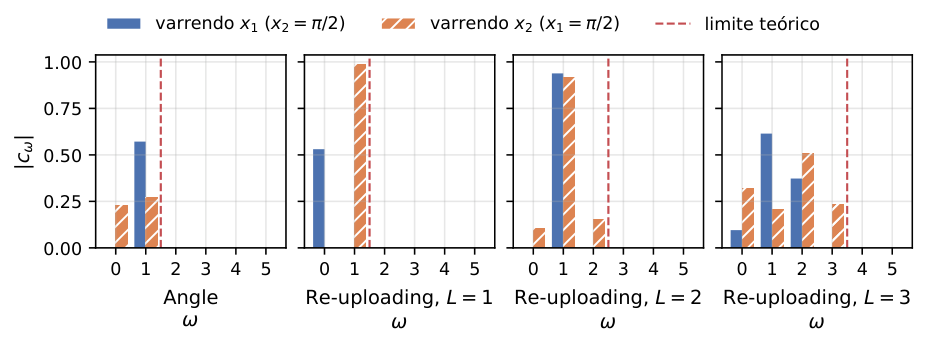

In [28]:
espectro = ler("espectro.csv")
if espectro is not None:
    display(espectro)
mostrar_tabela("tab_espectro")
mostrar_figura(FIGURES / "espectro-reuploading.pdf")

**Como interpretar.** $\Omega$ é um **limite superior**: diz quais frequências *podem*
aparecer. A coluna `dentro_do_limite` verifica que nenhuma energia escapa dele, e `atinge_limite`
diz se ele é alcançado. Na figura, cada atributo é varrido com o outro fixo em $\pi/2$, e a linha
tracejada é o limite teórico. Compare $x_1$ com $x_2$: no *re-uploading*, $x_1$ para em $L - 1$,
porque o anel de CNOTs e a medição local de $Z_0$ desperdiçam o último bloco de dados nesse
atributo. Essa perda é da arquitetura, não da codificação, e com $L = 1$ ela é total.

### 4.6 `ablacao`: o ansatz sem CNOTs

**Pergunta:** o classificador depende do entrelaçamento? (Previsão 3)

**O que faz:** treina o *angle* com o ansatz `local`, que tem as mesmas rotações genéricas e o
mesmo $p = 12$, mas nenhuma CNOT, nos três conjuntos, ao lado do ansatz padrão (30 treinos). É a
única execução que troca o ansatz. **Grava** `metrics/ablacao_entrelacamento.csv`. **Tempo:**
cerca de 3 minutos.

In [29]:
rodar_experimento(["ablacao"], ESPERADOS["ablacao"])

[pulado] os arquivos de `python -m tccqml --out results ablacao` já existem (ablacao_entrelacamento.csv).


In [30]:
ablacao = ler("ablacao_entrelacamento.csv")
tempo_de_treino(ablacao)
mostrar_tabela("tab_ablacao")
print("Este experimento não tem figura própria: o resultado é a tab_ablacao.")

30 treinos, 3.5 min de treino somados (coluna `segundos`)


**`tab_ablacao`** — mesma tabela de `results/tables/tab_ablacao.tex`

Ansatz,XOR,Moons,Circles
Com CNOTs,"0,873 ± 0,045","0,847 ± 0,032","0,953 ± 0,025"
Sem CNOTs,"0,533 ± 0,054","0,690 ± 0,028","0,807 ± 0,037"


Este experimento não tem figura própria: o resultado é a tab_ablacao.


**Como interpretar.** Sem CNOTs, o estado é produto e $\langle Z_0\rangle$ passa a depender só de
$x_1$. Espere uma queda em **todos** os conjuntos, e o *xor* no nível do acaso, porque nele
$x_1$ sozinho não informa o rótulo. A conclusão correta é que o modelo depende do entrelaçamento
**dado o observável local $Z_0$**. A ablação não mostra que o *xor* exige entrelaçamento: com o
mesmo estado produto, medir $Z_0 Z_1$ daria $\cos x_1 \cos x_2$, cujo sinal já é o padrão *xor*.

### 4.7 `diagnostico`: o amplitude e a normalização

**Pergunta:** o desempenho do *amplitude* é da codificação ou da normalização $[0, \pi]$, que foi
escolhida para o *angle*?

**O que faz:** treina o *amplitude* com os dados em $[0, \pi]$ (o protocolo) e em $[-1, 1]$
(centrados na origem), nos três conjuntos e 5 sementes (30 treinos). **Grava**
`metrics/diagnostico_amplitude.csv`, que o `tabelas` resume em `tab_diagnostico`. **Tempo:**
cerca de 4 minutos.

In [31]:
rodar_experimento(["diagnostico"], ESPERADOS["diagnostico"])

[pulado] os arquivos de `python -m tccqml --out results diagnostico` já existem (diagnostico_amplitude.csv).


In [32]:
diagnostico = ler("diagnostico_amplitude.csv")
tempo_de_treino(diagnostico)
mostrar_tabela("tab_diagnostico")
print("Este experimento não tem figura própria: o resultado é a tab_diagnostico.")

30 treinos, 1.8 min de treino somados (coluna `segundos`)


**`tab_diagnostico`** — mesma tabela de `results/tables/tab_diagnostico.tex`

Normalização,XOR,Moons,Circles
"[0, \pi] (usada no trabalho)","0,693 ± 0,069","0,827 ± 0,019","0,783 ± 0,051"
"[-1, 1]","0,870 ± 0,061","0,483 ± 0,029","0,513 ± 0,078"


Este experimento não tem figura própria: o resultado é a tab_diagnostico.


**Como interpretar.** O *amplitude* só vê a **direção** de $x$, e suas fronteiras são retas pela
origem. Em $[-1, 1]$ a origem fica no centro dos dados, e o *xor*, cujas classes se separam
pelos quadrantes, fica fácil. *moons* e *circles*, por outro lado, perdem a estrutura. O trabalho
mantém $[0, \pi]$ para todas as codificações porque só a codificação pode variar entre os
experimentos. O diagnóstico mostra o preço dessa escolha para o *amplitude*.

### 4.8 `verificacoes`: o que os próprios dados permitem

**Pergunta:** os limites observados são dos circuitos ou dos dados?

**O que faz:** duas checagens clássicas, sem circuito, com as mesmas partições, normalização e
sementes da grade.

- **Controle linear**: uma regressão logística ($C = 1$, até 1000 iterações, fixados antes de
  rodar) sobre as nove funções $\{1, \cos x_j, \sin x_j\}$ e seus produtos, o espaço de frequência
  1 do *angle*.
- **Limiar de $g$ no circles**: a regra "classe 1 se $g(x) > t$", com
  $g(x) = (\sin x_1 + \sin x_2)/2$ e o limiar escolhido no treino, sem ruído e com o ruído do
  protocolo.

**Grava** `metrics/controle_linear.csv`, `metrics/limiar_circles.csv` e os respectivos
`resumo_*.csv`. **Tempo:** segundos.

In [33]:
rodar_experimento(["verificacoes"], ESPERADOS["verificacoes"])

[pulado] os arquivos de `python -m tccqml --out results verificacoes` já existem (controle_linear.csv, resumo_controle_linear.csv, limiar_circles.csv e mais 1).


**`resumo_controle_linear.csv`**

,dataset,acc_treino_mean,acc_treino_std,acc_val_mean,acc_val_std,acc_teste_mean,acc_teste_std,n_sementes
0,xor,0.900000,0.022567,0.866667,0.026352,0.873333,0.045031,5
1,moons,0.887778,0.026759,0.880000,0.060553,0.850000,0.039087,5
2,circles,0.973333,0.002485,0.983333,0.020412,0.963333,0.021731,5


**`resumo_limiar_circles.csv`**

,versao,limiar_mean,limiar_std,acc_treino_mean,acc_treino_std,acc_val_mean,acc_val_std,acc_teste_mean,acc_teste_std,g_sobreposicao_mean,g_sobreposicao_std,n_sementes
0,sem_ruido,0.701264,0.000215,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,5
1,com_ruido,0.805889,0.014415,0.972222,0.008784,0.963333,0.027386,0.966667,0.020412,0.135556,0.030072,5


**`tab_verificacoes`** — mesma tabela de `results/tables/tab_verificacoes.tex`

Verificação,XOR,Moons,Circles
Controle linear (9 funções),"0,873 ± 0,045","0,850 ± 0,039","0,963 ± 0,022"
"g > t, sem ruído",—,—,"1,000 ± 0,000"
"g > t, ruído 0,15",—,—,"0,967 ± 0,020"


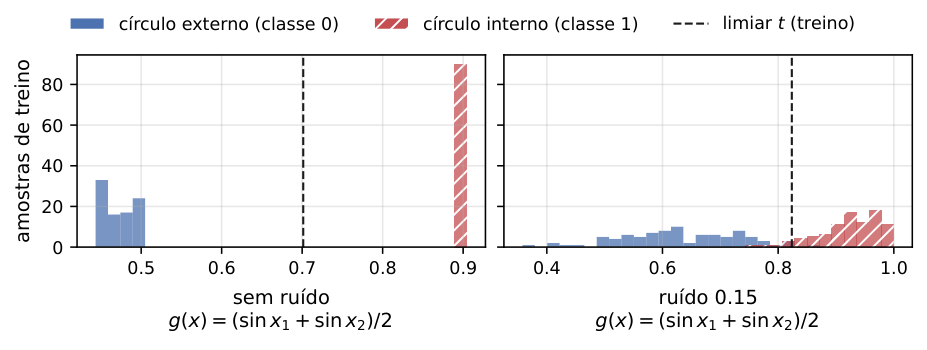

In [34]:
for nome in ("resumo_controle_linear.csv", "resumo_limiar_circles.csv"):
    tabela = ler(nome)
    if tabela is not None:
        display(Markdown(f"**`{nome}`**"))
        display(tabela)
mostrar_tabela("tab_verificacoes")
mostrar_figura(FIGURES / "limiar-circles.pdf")

**Como interpretar.** Se o controle linear empata com o *angle*, o *angle* já está no nível de um
separador linear treinado no seu próprio espaço de frequências. O teto dele é então do espaço de
funções, não do treino, o que concorda com a `sensibilidade` (4.2) e a `tab_mesmo_p` (4.4). Um
controle linear acerta o que o espaço *contém*, não o que o circuito consegue aprender. No
*circles*, $g$ separa as classes por completo sem ruído. Com ruído, os histogramas se sobrepõem,
e o limite de acurácia nesse conjunto vem do ruído, não da forma da fronteira.

## 5. Tabelas e figuras finais

`tabelas` grava `.tex` (colável no Overleaf) e `.csv` em `OUT_DIR/tables/`. `figuras` grava os
PDFs vetoriais em `OUT_DIR/figures/`. Os dois só leem CSV e nunca treinam. A coluna "no TCC"
segue o relatório atual (capítulos "O experimento" e "Resultados").

In [35]:
rodar_se_preciso(["tabelas"], SAIDAS_TABELAS)
rodar_se_preciso(["figuras"], SAIDAS_FIGURAS);

[pulado] os arquivos de `python -m tccqml --out results tabelas` já existem (tab_acuracia.tex, tab_acuracia.csv, tab_custo.tex e mais 17).
[pulado] os arquivos de `python -m tccqml --out results figuras` já existem (datasets.pdf, curvas-treinamento.pdf, fronteiras-aprendidas.pdf e mais 6).


In [36]:
TABELAS_TCC = {
    "tab_acuracia": "Resultados › Acurácia de teste (tab:acuracia)",
    "tab_custo": "Resultados › Custo dos circuitos (tab:custo)",
    "tab_convergencia": "só no pacote .zip; o texto mostra as curvas (fig:curvas)",
    "tab_espectro": "Resultados › Espectro de Fourier medido (tab:espectro)",
    "tab_ablacao": "Resultados › Ablação e normalização dos dados (tab:ablacao)",
    "tab_diagnostico": "Resultados › Ablação e normalização dos dados (tab:diagnostico)",
    "tab_mesmo_p": "Resultados › Número de repetições do re-uploading (tab:mesmo-p; as colunas de re-uploading são a tab:varredura)",
    "tab_sensibilidade": "Resultados › Sensibilidade à taxa de aprendizado (tab:sensibilidade)",
    "tab_verificacoes": "Resultados › Verificações sobre os dados (tab:verificacoes)",
    "tab_qualitativa": "não usada no relatório atual (o texto vive em tabelas.QUALITATIVA)",
}
FIGURAS_TCC = {
    "datasets.pdf": "O experimento (fig:datasets)",
    "fronteiras-aprendidas.pdf": "Resultados › Fronteiras de decisão (fig:fronteiras)",
    "curvas-treinamento.pdf": "Resultados › Curvas de treinamento (fig:curvas)",
    "acuracia-vs-custo.pdf": "Resultados › Custo dos circuitos (fig:acc-custo)",
    "custo-por-codificacao.pdf": "só no pacote .zip; repete a tab:custo em barras",
    "acuracia-vs-L.pdf": "Resultados › Número de repetições do re-uploading (fig:acc-L)",
    "espectro-reuploading.pdf": "Resultados › Espectro de Fourier medido (fig:espectro)",
    "sensibilidade-lr.pdf": "Resultados › Sensibilidade à taxa de aprendizado (fig:sensibilidade)",
    "limiar-circles.pdf": "Resultados › Verificações sobre os dados (fig:limiar)",
}
display(pd.DataFrame(
    [{"arquivo": f"tables/{t}.tex", "existe": (TABLES / f"{t}.tex").exists(), "no TCC": TABELAS_TCC[t]} for t in TABELAS]
    + [{"arquivo": f"figures/{f}", "existe": (FIGURES / f).exists(), "no TCC": FIGURAS_TCC[f]} for f in FIGURAS]
).style.hide(axis="index"))

arquivo,existe,no TCC
tables/tab_acuracia.tex,True,Resultados › Acurácia de teste (tab:acuracia)
tables/tab_custo.tex,True,Resultados › Custo dos circuitos (tab:custo)
tables/tab_convergencia.tex,True,só no pacote .zip; o texto mostra as curvas (fig:curvas)
tables/tab_espectro.tex,True,Resultados › Espectro de Fourier medido (tab:espectro)
tables/tab_ablacao.tex,True,Resultados › Ablação e normalização dos dados (tab:ablacao)
tables/tab_diagnostico.tex,True,Resultados › Ablação e normalização dos dados (tab:diagnostico)
tables/tab_mesmo_p.tex,True,Resultados › Número de repetições do re-uploading (tab:mesmo-p; as colunas de re-uploading são a tab:varredura)
tables/tab_sensibilidade.tex,True,Resultados › Sensibilidade à taxa de aprendizado (tab:sensibilidade)
tables/tab_verificacoes.tex,True,Resultados › Verificações sobre os dados (tab:verificacoes)
tables/tab_qualitativa.tex,True,não usada no relatório atual (o texto vive em tabelas.QUALITATIVA)


In [37]:
for tabela in TABELAS:
    display(Markdown(f"#### `{tabela}`: {TABELAS_TCC[tabela]}"))
    mostrar_tabela(tabela)

#### `tab_acuracia`: Resultados › Acurácia de teste (tab:acuracia)

**`tab_acuracia`** — mesma tabela de `results/tables/tab_acuracia.tex`

Codificação,XOR,Moons,Circles
Angle,"0,873 ± 0,045","0,847 ± 0,032","0,953 ± 0,025"
Amplitude,"0,693 ± 0,069","0,827 ± 0,019","0,783 ± 0,051"
Re-uploading,"0,870 ± 0,046","0,890 ± 0,045","0,957 ± 0,022"
Feature map ZZ,"0,683 ± 0,024","0,750 ± 0,068","0,880 ± 0,030"


#### `tab_custo`: Resultados › Custo dos circuitos (tab:custo)

**`tab_custo`** — mesma tabela de `results/tables/tab_custo.tex`

...

**`tab_verificacoes`** — mesma tabela de `results/tables/tab_verificacoes.tex`

Verificação,XOR,Moons,Circles
Controle linear (9 funções),"0,873 ± 0,045","0,850 ± 0,039","0,963 ± 0,022"
"g > t, sem ruído",—,—,"1,000 ± 0,000"
"g > t, ruído 0,15",—,—,"0,967 ± 0,020"


#### `tab_qualitativa`: não usada no relatório atual (o texto vive em tabelas.QUALITATIVA)

**`tab_qualitativa`** — mesma tabela de `results/tables/tab_qualitativa.tex`

Codificação,Ponto forte,Ponto fraco,Dificuldade,Observação
Angle,"circuito raso, um qubit por atributo, custo mínimo","espectro limitado a Ω = {-1,0,1} por atributo",baixa,primitiva pronta no PennyLane; nenhuma armadilha
Amplitude,⌈ log₂ d ⌉ qubits: o menor número de qubits,descarta a norma do vetor; fronteira quádrica homogênea,média,a normalização dos dados interage com a codificação e precisa de diagnóstico próprio
Re-uploading,"espectro cresce com L: Ω = {-L,…,L}",profundidade e p crescem linearmente com L,média,não cabe no formato codifica e depois aplica o ansatz; exigiu generalizar a montagem do circuito
Feature map ZZ,insere correlações entre atributos no bloco de dados,r d(d-1) CNOTs e profundidade O(r d^2),alta,construção explícita; sem as Hadamards o operador é diagonal e o circuito fica inerte sem dar erro


#### `datasets.pdf`: O experimento (fig:datasets)

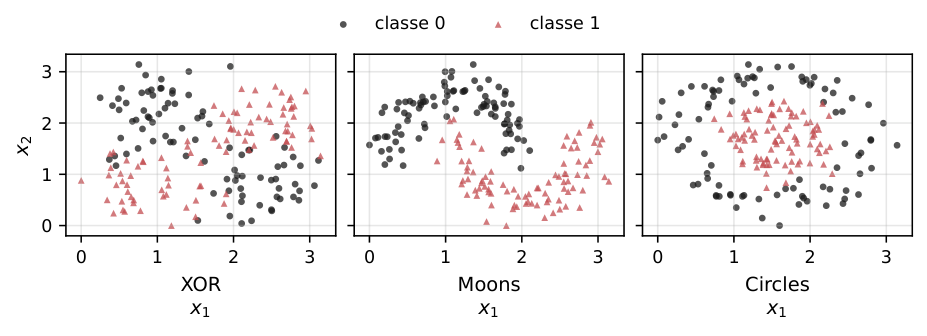

#### `curvas-treinamento.pdf`: Resultados › Curvas de treinamento (fig:curvas)

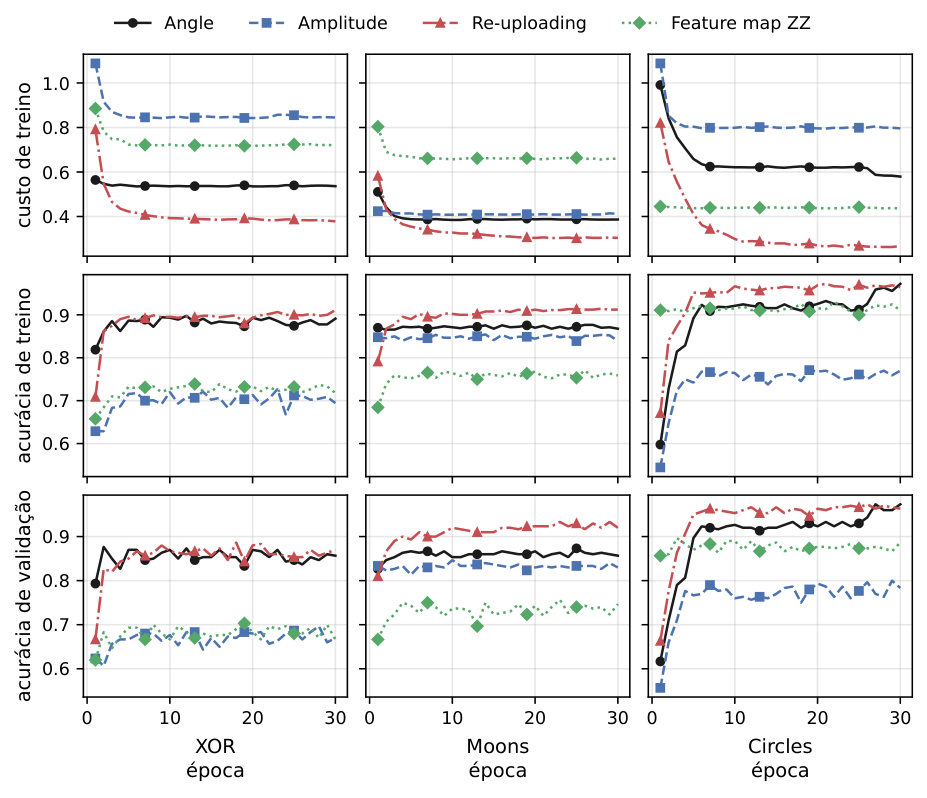

#### `fronteiras-aprendidas.pdf`: Resultados › Fronteiras de decisão (fig:fronteiras)

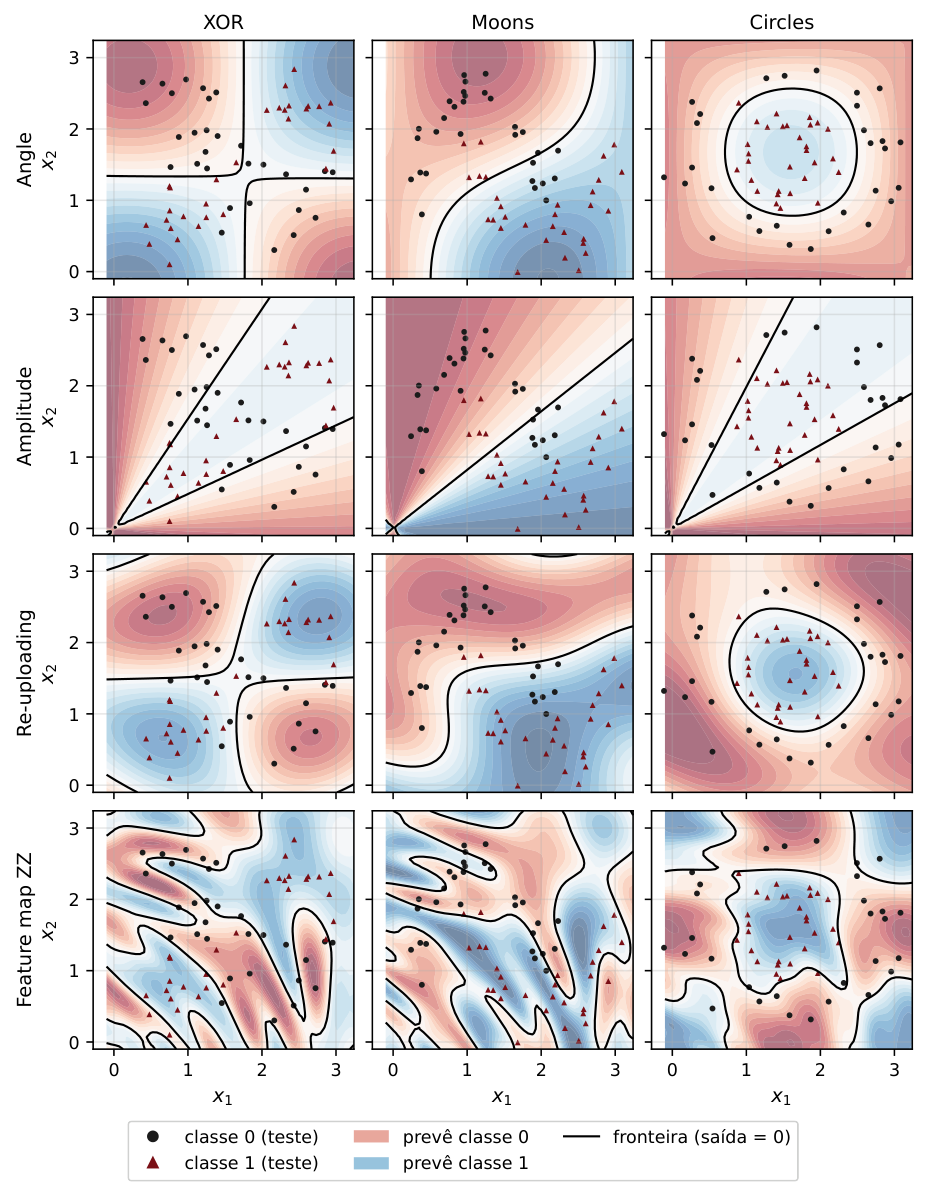

#### `acuracia-vs-custo.pdf`: Resultados › Custo dos circuitos (fig:acc-custo)

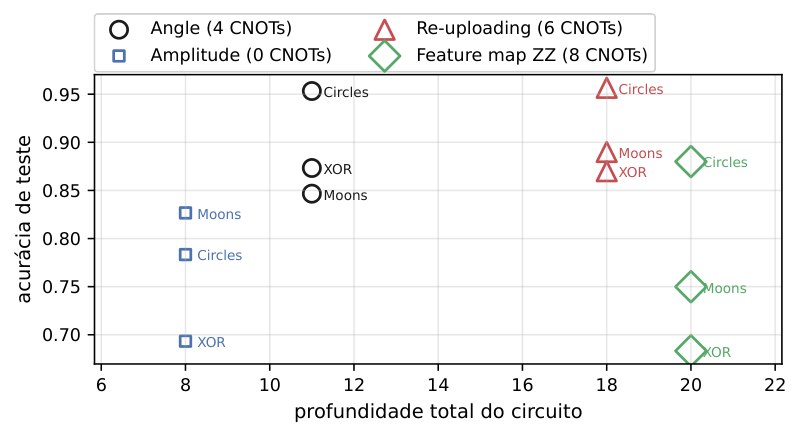

#### `custo-por-codificacao.pdf`: só no pacote .zip; repete a tab:custo em barras

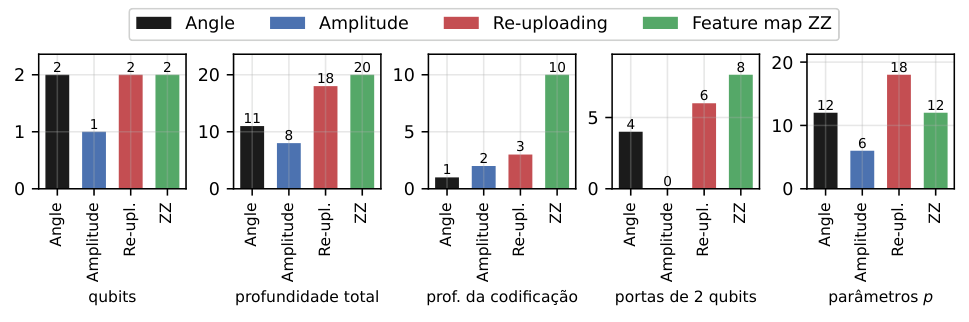

#### `acuracia-vs-L.pdf`: Resultados › Número de repetições do re-uploading (fig:acc-L)

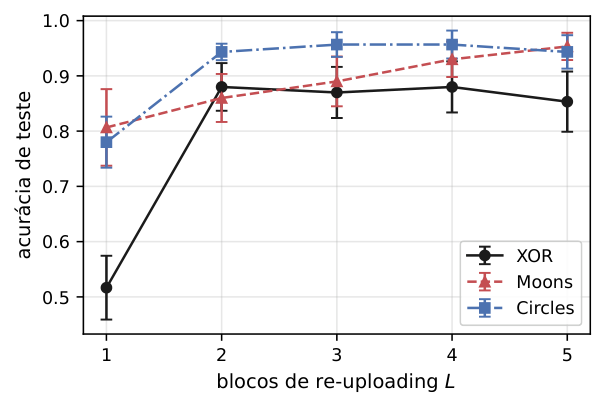

#### `espectro-reuploading.pdf`: Resultados › Espectro de Fourier medido (fig:espectro)

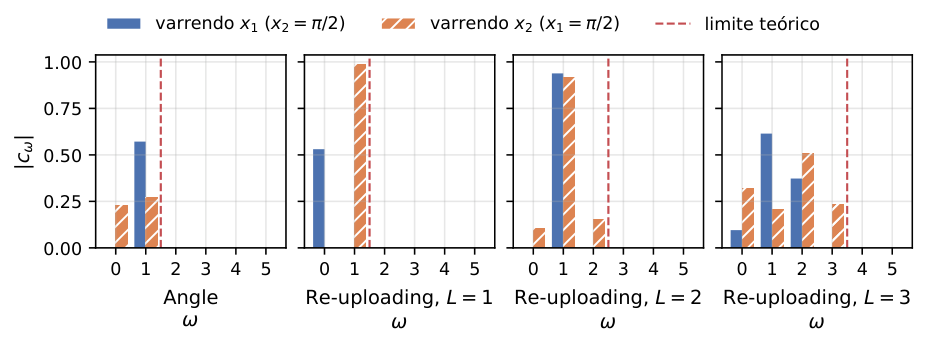

#### `sensibilidade-lr.pdf`: Resultados › Sensibilidade à taxa de aprendizado (fig:sensibilidade)

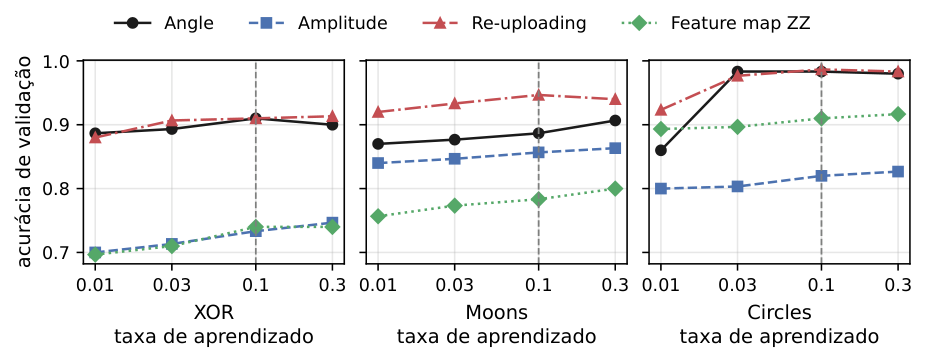

#### `limiar-circles.pdf`: Resultados › Verificações sobre os dados (fig:limiar)

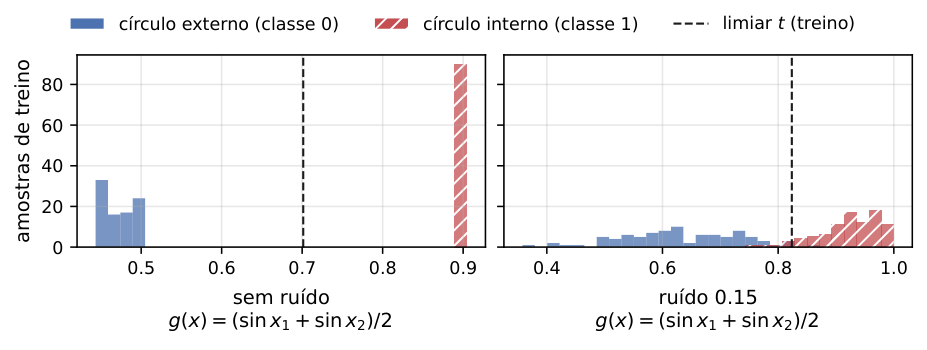

In [38]:
for figura in FIGURAS:
    display(Markdown(f"#### `{figura}`: {FIGURAS_TCC[figura]}"))
    mostrar_figura(FIGURES / figura)

## 6. Resumo

| Subcomando | Pergunta | Arquivos gerados (`OUT_DIR/`) | Figuras | Onde aparece no TCC |
|---|---|---|---|---|
| `listar` | O que está registrado e qual é o protocolo? | — | — | — |
| `treinar` | Como uma combinação treina, e a que custo? | com `--salvar`: `metrics/treino_*.csv`, `metrics/treino_*_resumo.csv`, `weights/treino_*.npz` | — (o notebook desenha as suas) | — |
| `comparar` | Qual codificação classifica melhor, e a que custo? | `metrics/comparacao.csv`, `por_treino.csv`, `resumo.csv`; `weights/*.npz` | `fronteiras-aprendidas`, `curvas-treinamento`, `acuracia-vs-custo`, `custo-por-codificacao` | Resultados: acurácia, fronteiras, curvas, custo |
| `sensibilidade` | O lr comum prejudicou alguma codificação? | `metrics/sensibilidade_lr.csv`, `resumo_sensibilidade_lr.csv` | `sensibilidade-lr` | Resultados: sensibilidade à taxa de aprendizado |
| `varredura --parametro L-reup` | Quantos blocos o re-uploading precisa? | `metrics/varredura_L.csv` | `acuracia-vs-L` | Resultados: número de repetições do re-uploading |
| `varredura --parametro n-layers` | O ganho vem das frequências ou dos parâmetros? | `metrics/varredura_camadas.csv` | — | Resultados: mesma seção (tab:mesmo-p) |
| `espectro` | O $\Omega$ medido respeita o previsto? | `metrics/espectro.csv` | `espectro-reuploading` | Resultados: espectro de Fourier medido |
| `ablacao` | O modelo depende do entrelaçamento? | `metrics/ablacao_entrelacamento.csv` | — | Resultados: ablação e normalização |
| `diagnostico` | O amplitude sofre com a normalização $[0, \pi]$? | `metrics/diagnostico_amplitude.csv` (resumido em `tab_diagnostico`) | — | Resultados: ablação e normalização (tab:diagnostico) |
| `verificacoes` | Os limites são dos circuitos ou dos dados? | `metrics/controle_linear.csv`, `limiar_circles.csv` e os `resumo_*` | `limiar-circles` | Resultados: verificações sobre os dados |
| `tabelas` | — | `tables/tab_*.tex` e `.csv` | — | todas as tabelas derivadas |
| `figuras` | — | `figures/*.pdf` (inclusive `datasets.pdf`) | todas | todas as figuras |

### A sequência completa no terminal

Da raiz do repositório, com o ambiente ativado:

```bash
pip install -r requirements-lock.txt
pip install -e ".[dev,notebooks]"
pytest

python -m tccqml listar
python -m tccqml comparar
python -m tccqml sensibilidade
python -m tccqml varredura --parametro L-reup
python -m tccqml varredura --parametro n-layers
python -m tccqml espectro
python -m tccqml ablacao
python -m tccqml diagnostico
python -m tccqml verificacoes
python -m tccqml tabelas
python -m tccqml figuras

# opcional: uma combinação isolada, com pesos para desenhar a fronteira
python -m tccqml --out results/notebook treinar --encoding reuploading --dataset circles --salvar
```